# Patent Analysis - Modularized Notebook

This notebook performs comprehensive patent analysis using modularized functions from `utils/patent_utils.py`. 
It covers:
- Data loading and preparation
- Abstract cleaning
- Country assignment from assignees
- Topic parsing and hierarchical classification
- LLM-based classification (using pre-computed results to skip re-running)
- Summary statistics and visualizations
- Data export

**Note**: LLM classification results are loaded from saved checkpoints, so no actual LLM calls are made in this notebook.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import ast
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Make `src` importable and anchor all paths on the repo root, regardless of the
# directory this notebook is launched from (repo root, src/, or src/data_analysis/).
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "utils").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import shared_paths as P
P.bootstrap()

# Import modularized patent-analysis functions.
from utils import shared_patent_utils as patent

# Define color scheme for visualizations
colors_scheme = ["#B80C09", "#D4AF37", "#6E8B3D", "#345995"]

# Set plot style
plt.rcParams['figure.dpi'] = 300

## 1. Load Patent Data

Load the main patent dataset and reference data (UK Biobank papers).

In [2]:
# Load patent data
df_patent = pd.read_csv(P.PATENTS_DETAILED)

# UK Biobank paper corpus — now the showcase-plus parquet (replaces df_dimensions.xlsx).
# Only `id` (citation matching) and a few display columns are needed downstream.
from utils.shared_showcase import load_showcase
df_all_ukbb = load_showcase(columns=["id", "title", "year", "times_cited"])

print(f"✓ Patents loaded: {len(df_patent)} patents")
print(f"✓ UK Biobank papers loaded: {len(df_all_ukbb)} papers")
print(f"\nPatent data shape: {df_patent.shape}")
print(f"Missing abstracts: {df_patent['abstract'].isnull().sum()}")
print(f"\nSample columns: {df_patent.columns.tolist()[:10]}")

✓ Patents loaded: 513 patents
✓ UK Biobank papers loaded: 26109 papers

Patent data shape: (513, 56)
Missing abstracts: 16

Sample columns: ['abstract', 'additional_filters', 'application_number', 'assignee_cities', 'assignee_countries', 'assignee_names', 'assignees', 'category_for', 'category_for_2020', 'category_rcdc']


## 2. Data Preparation and Cleaning

Clean patent abstracts and prepare data for analysis.

In [3]:
# Clean abstracts using modularized function
df_patent["abstract_clean"] = df_patent["abstract"].apply(patent.clean_patent_abstract)

# Prepare publication dates
df_patent['publication_date'] = pd.to_datetime(df_patent['publication_date'], errors='coerce')
df_patent['publication_year'] = df_patent['publication_date'].dt.year
df_patent['year'] = df_patent['publication_year']

print(f"✓ Abstracts cleaned: {df_patent['abstract_clean'].notna().sum()} non-null abstracts")
print(f"✓ Publication dates processed: {df_patent['publication_year'].notna().sum()} valid dates")
print(f"\nYear range: {df_patent['publication_year'].min():.0f} - {df_patent['publication_year'].max():.0f}")

✓ Abstracts cleaned: 497 non-null abstracts
✓ Publication dates processed: 513 valid dates

Year range: 2018 - 2025


## 3. Country Assignment from Assignees

Assign country information to patents using patent assignee metadata.

In [4]:
# Assign country information using modularized function
# Use aggressive mode to include rule-based inference
df_with_iso = patent.assign_assignee_countries_with_iso(
    df_patent,
    assignee_col='assignees',
    assignee_names_col='assignee_names',
    use_low_confidence=True,
    primary_pick='most_common'
)

print(f"✓ Country assignment completed")
print(f"✓ Patents with country info: {df_with_iso['assignee_countries'].notna().sum()}")
print(f"\nTop 10 countries:")
all_countries = []
for countries in df_with_iso['assignee_countries']:
    if isinstance(countries, list):
        all_countries.extend(countries)

country_counts = Counter(all_countries)
for country, count in country_counts.most_common(10):
    print(f"  {country}: {count}")


✓ Country assignment completed
✓ Patents with country info: 513

Top 10 countries:
  US: 268
  GB: 65
  FR: 53
  KR: 37
  None: 34
  CN: 31
  DE: 27
  JP: 18
  BE: 13
  CH: 12


## 4. Topic Parsing and Hierarchical Classification

Parse patent topics and organize them hierarchically by FOR (Field of Research) codes.

In [5]:
# Parse patent topics using modularized function
df_with_iso = patent.parse_patent_topics(df_with_iso, category_col='category_for')

print(f"✓ Topics parsed for patents")
print(f"✓ Patents with topic data: {df_with_iso['topics_list'].notna().sum()}")

# Calculate topic statistics
df_with_iso['n_topics'] = df_with_iso['topics_list'].apply(len)
avg_topics = df_with_iso['n_topics'].mean()
median_topics = df_with_iso['n_topics'].median()

print(f"\nTopic statistics:")
print(f"  Average topics per patent: {avg_topics:.2f}")
print(f"  Median topics per patent: {median_topics:.0f}")
print(f"  Max topics in a patent: {df_with_iso['n_topics'].max()}")


✓ Topics parsed for patents
✓ Patents with topic data: 513

Topic statistics:
  Average topics per patent: 3.23
  Median topics per patent: 3
  Max topics in a patent: 9


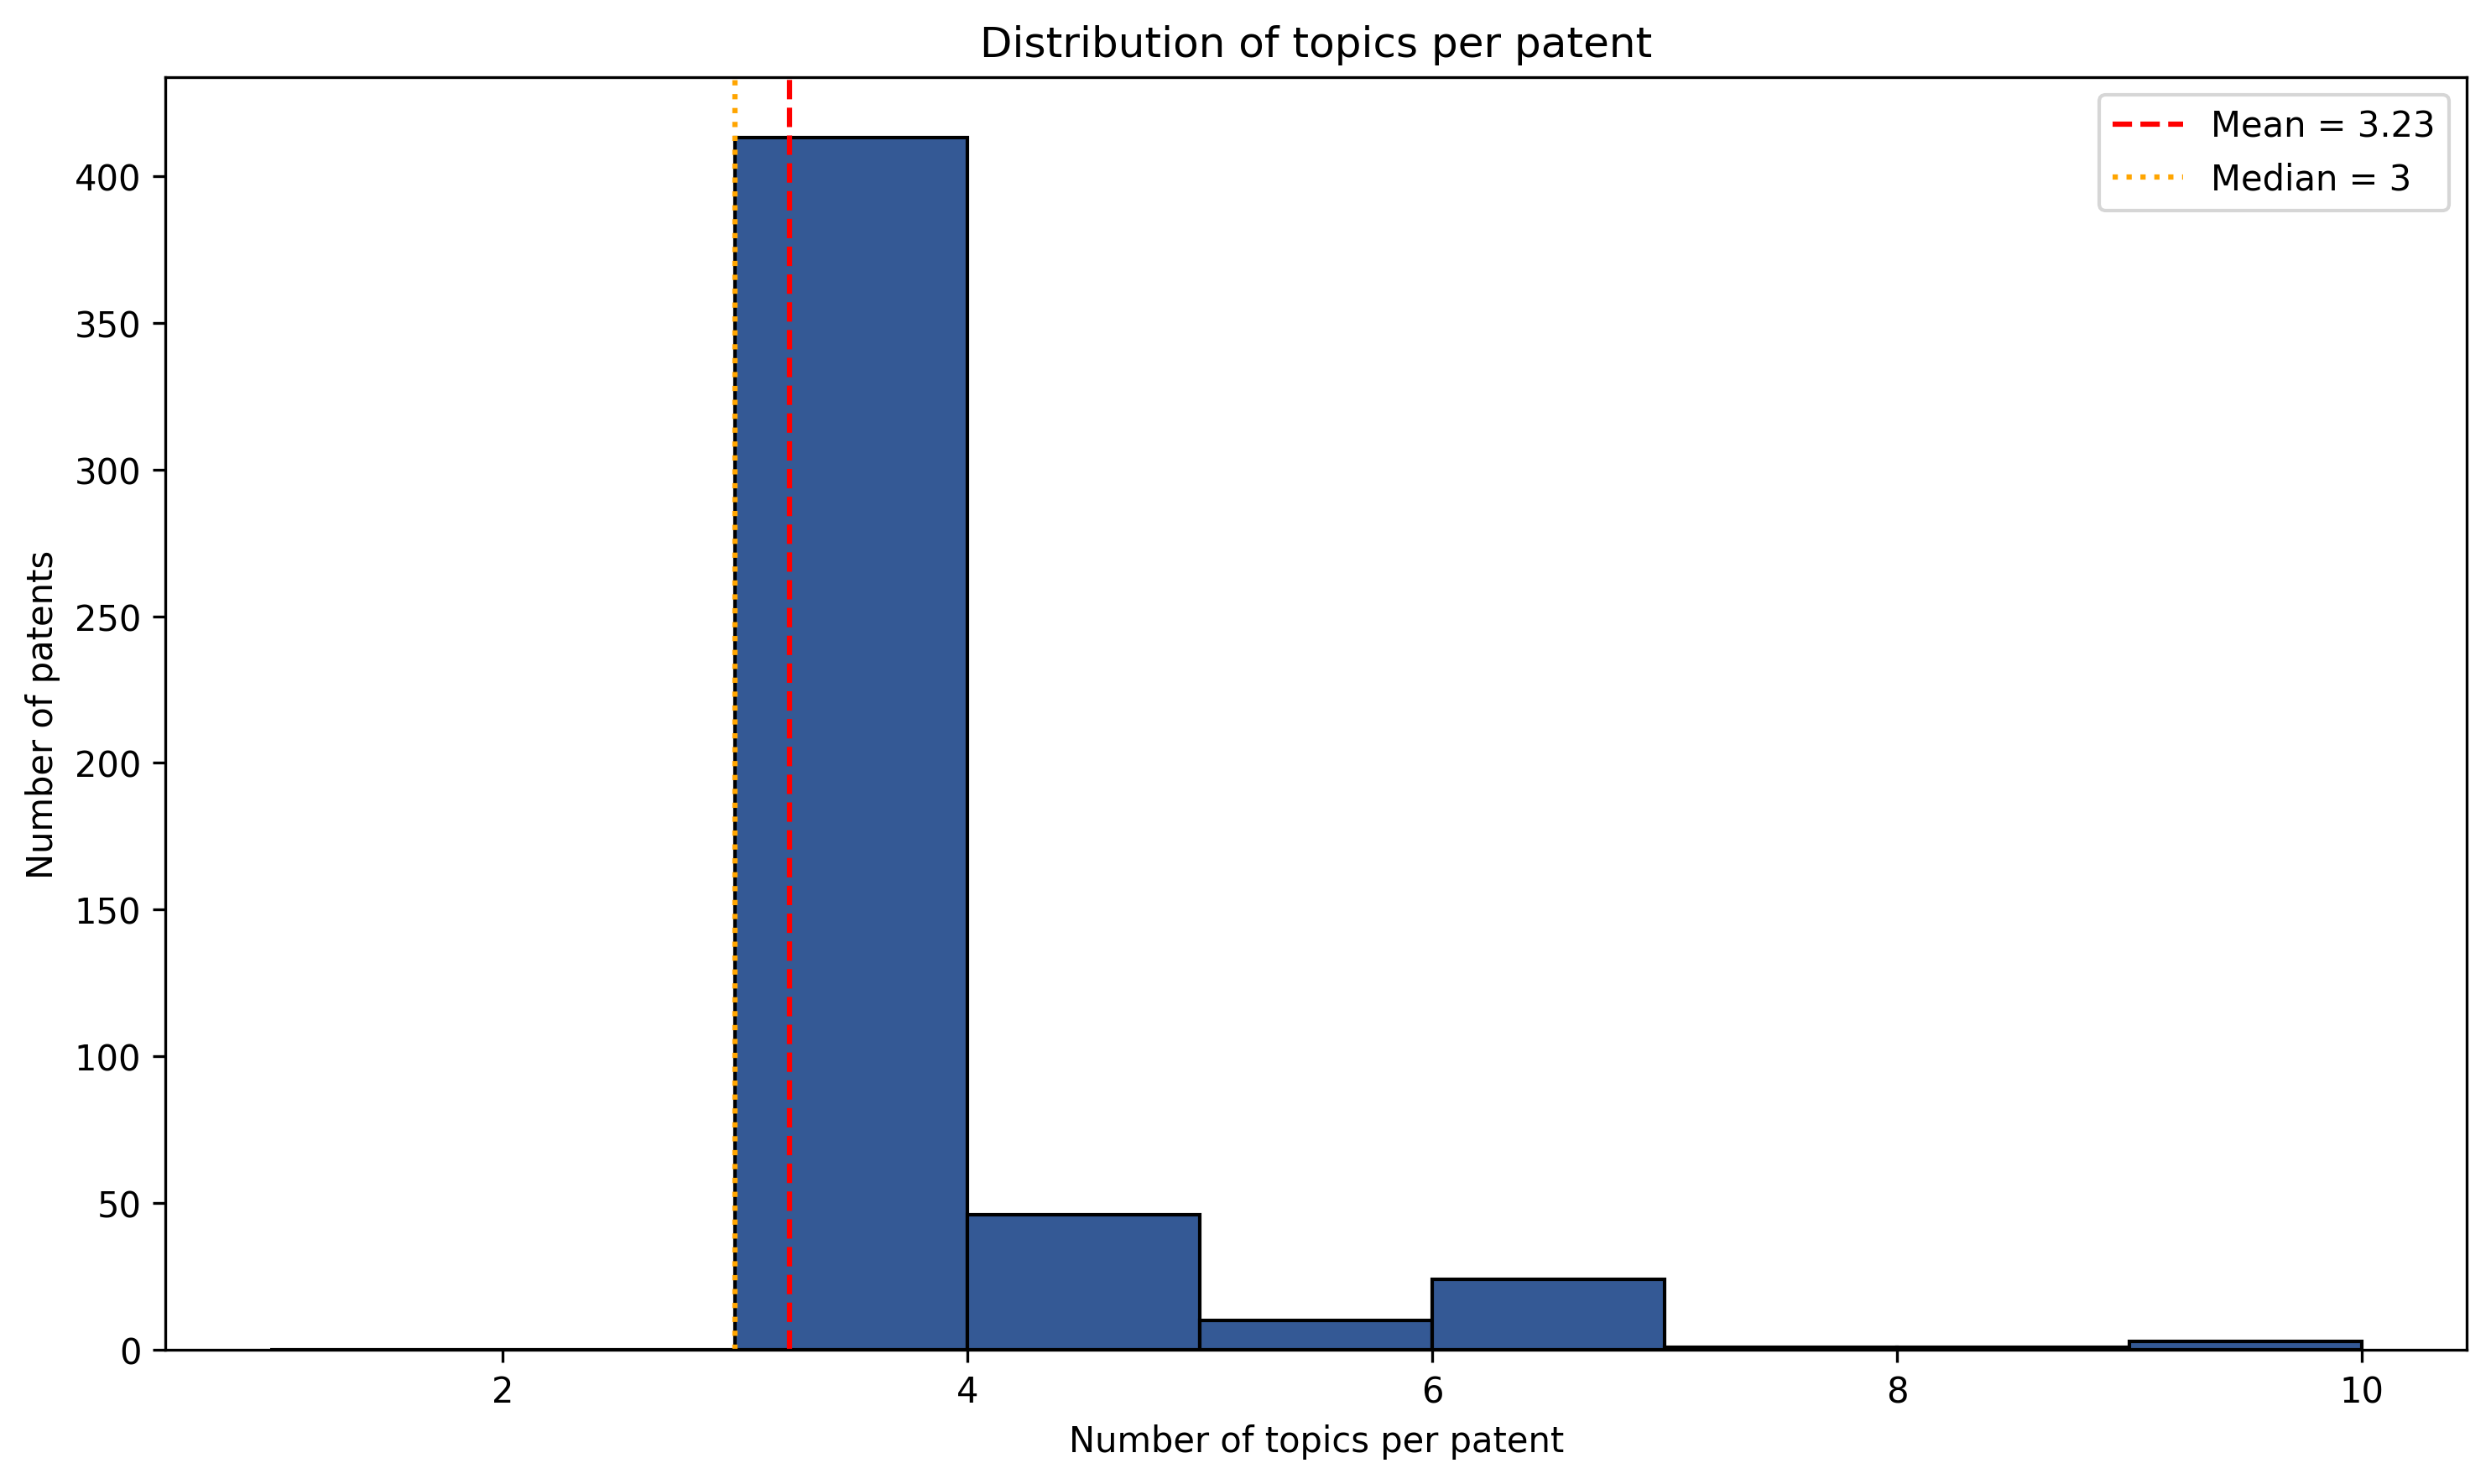

In [6]:
# Visualize topic distribution
patent.plot_topics_histogram(
    df_with_iso,
    n_topics_col='n_topics',
    colors=colors_scheme[3],
    figsize=(10, 6),
    savefile=None
)

✓ Found 69 unique topics


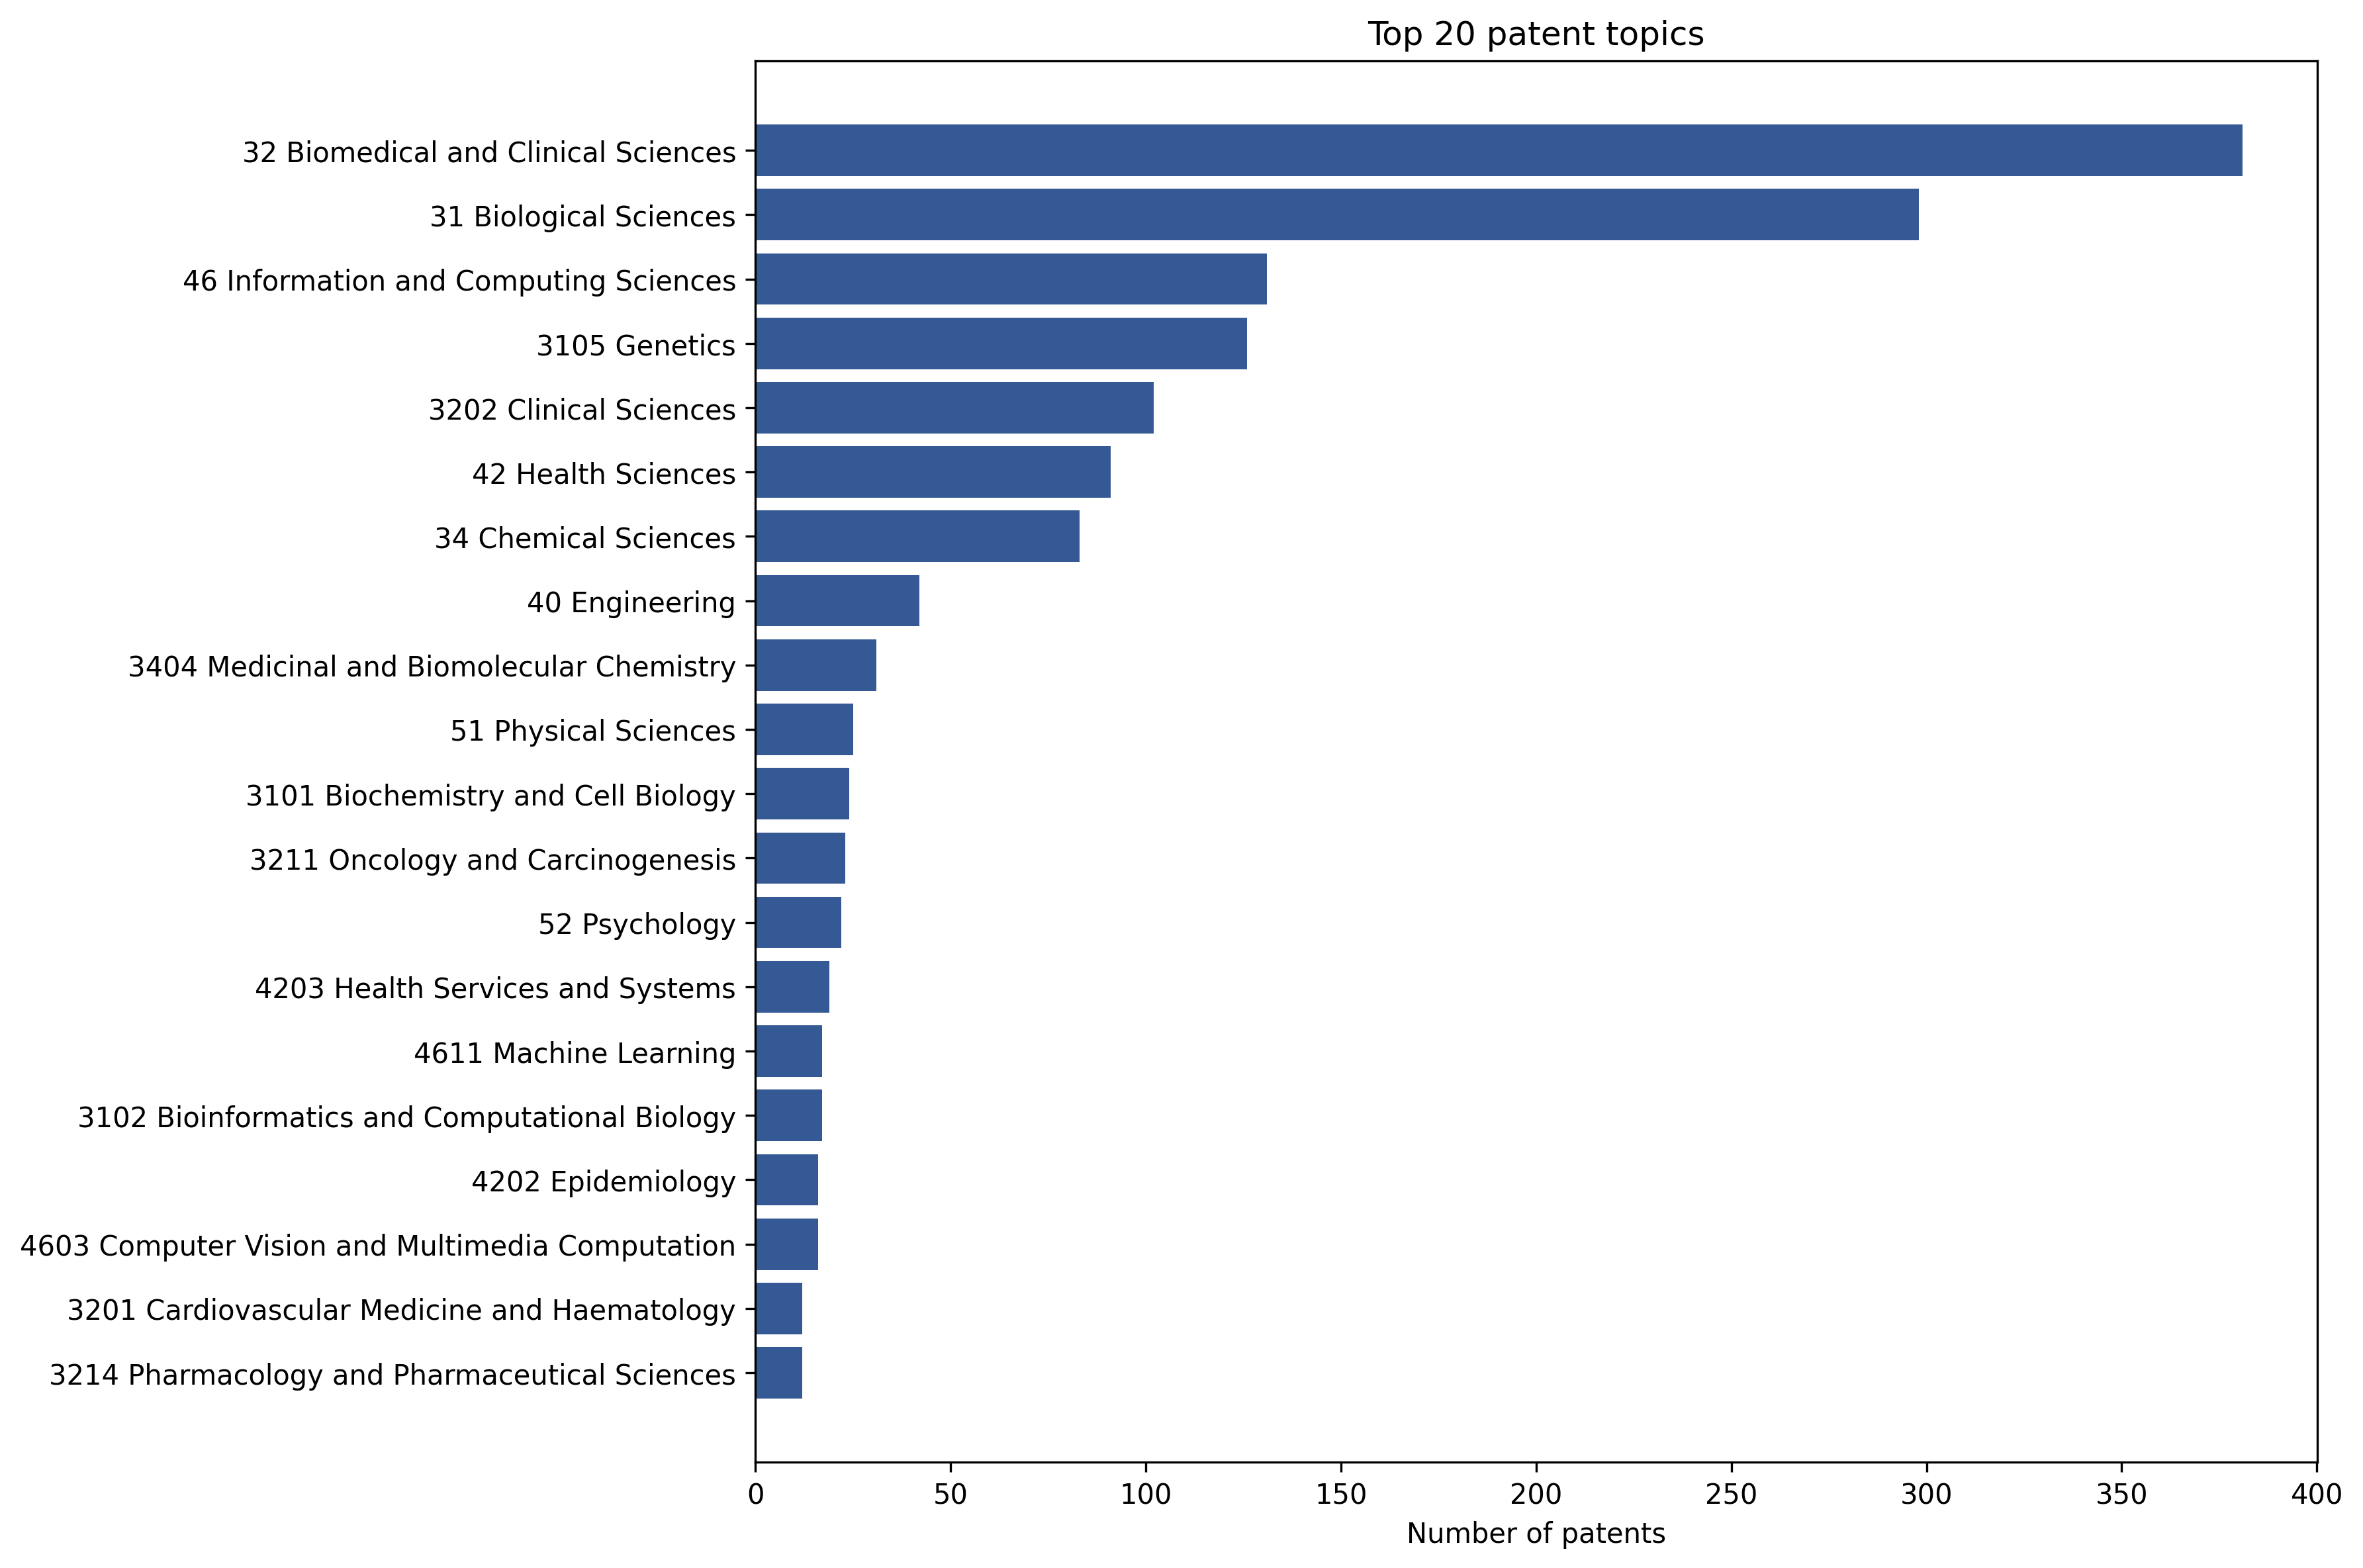

In [7]:
# Build top-level topic counts (fractional counting)
topic_counter = Counter()
for topics in df_with_iso['topics_list']:
    for t in topics:
        topic_counter[t] += 1

topic_df = (
    pd.DataFrame(topic_counter.items(), columns=['topic', 'count'])
    .sort_values('count', ascending=False)
    .reset_index(drop=True)
)

print(f"✓ Found {len(topic_df)} unique topics")

# Visualize top topics
patent.plot_top_topics_horizontal(
    topic_df,
    topic_col='topic',
    count_col='count',
    top_n=20,
    colors=[colors_scheme[3]],
    figsize=(12, 8),
    savefile=None #'fig/patent/top_topics.png'
)

## 4.1 RCDC Macro-Cluster Mapping and Hierarchy

This section mirrors the original RCDC outputs: the macro-to-category tree look plot and the categories-per-cluster heatmap with matching palette intent.

In [8]:
# Prepare shared RCDC macro-cluster context
import importlib
patent = importlib.reload(patent)

rcdc_context = patent.prepare_rcdc_macro_context(
    df_with_iso,
    category_col='category_rcdc',
    summary_csv=P.PATENT_RCDC_SUMMARY,
)

cat_dict = rcdc_context['cat_dict']
macro_cluster_names = rcdc_context['macro_cluster_names']
top_topic_dict = rcdc_context['top_topic_dict']
code_to_macro = rcdc_context['code_to_macro']

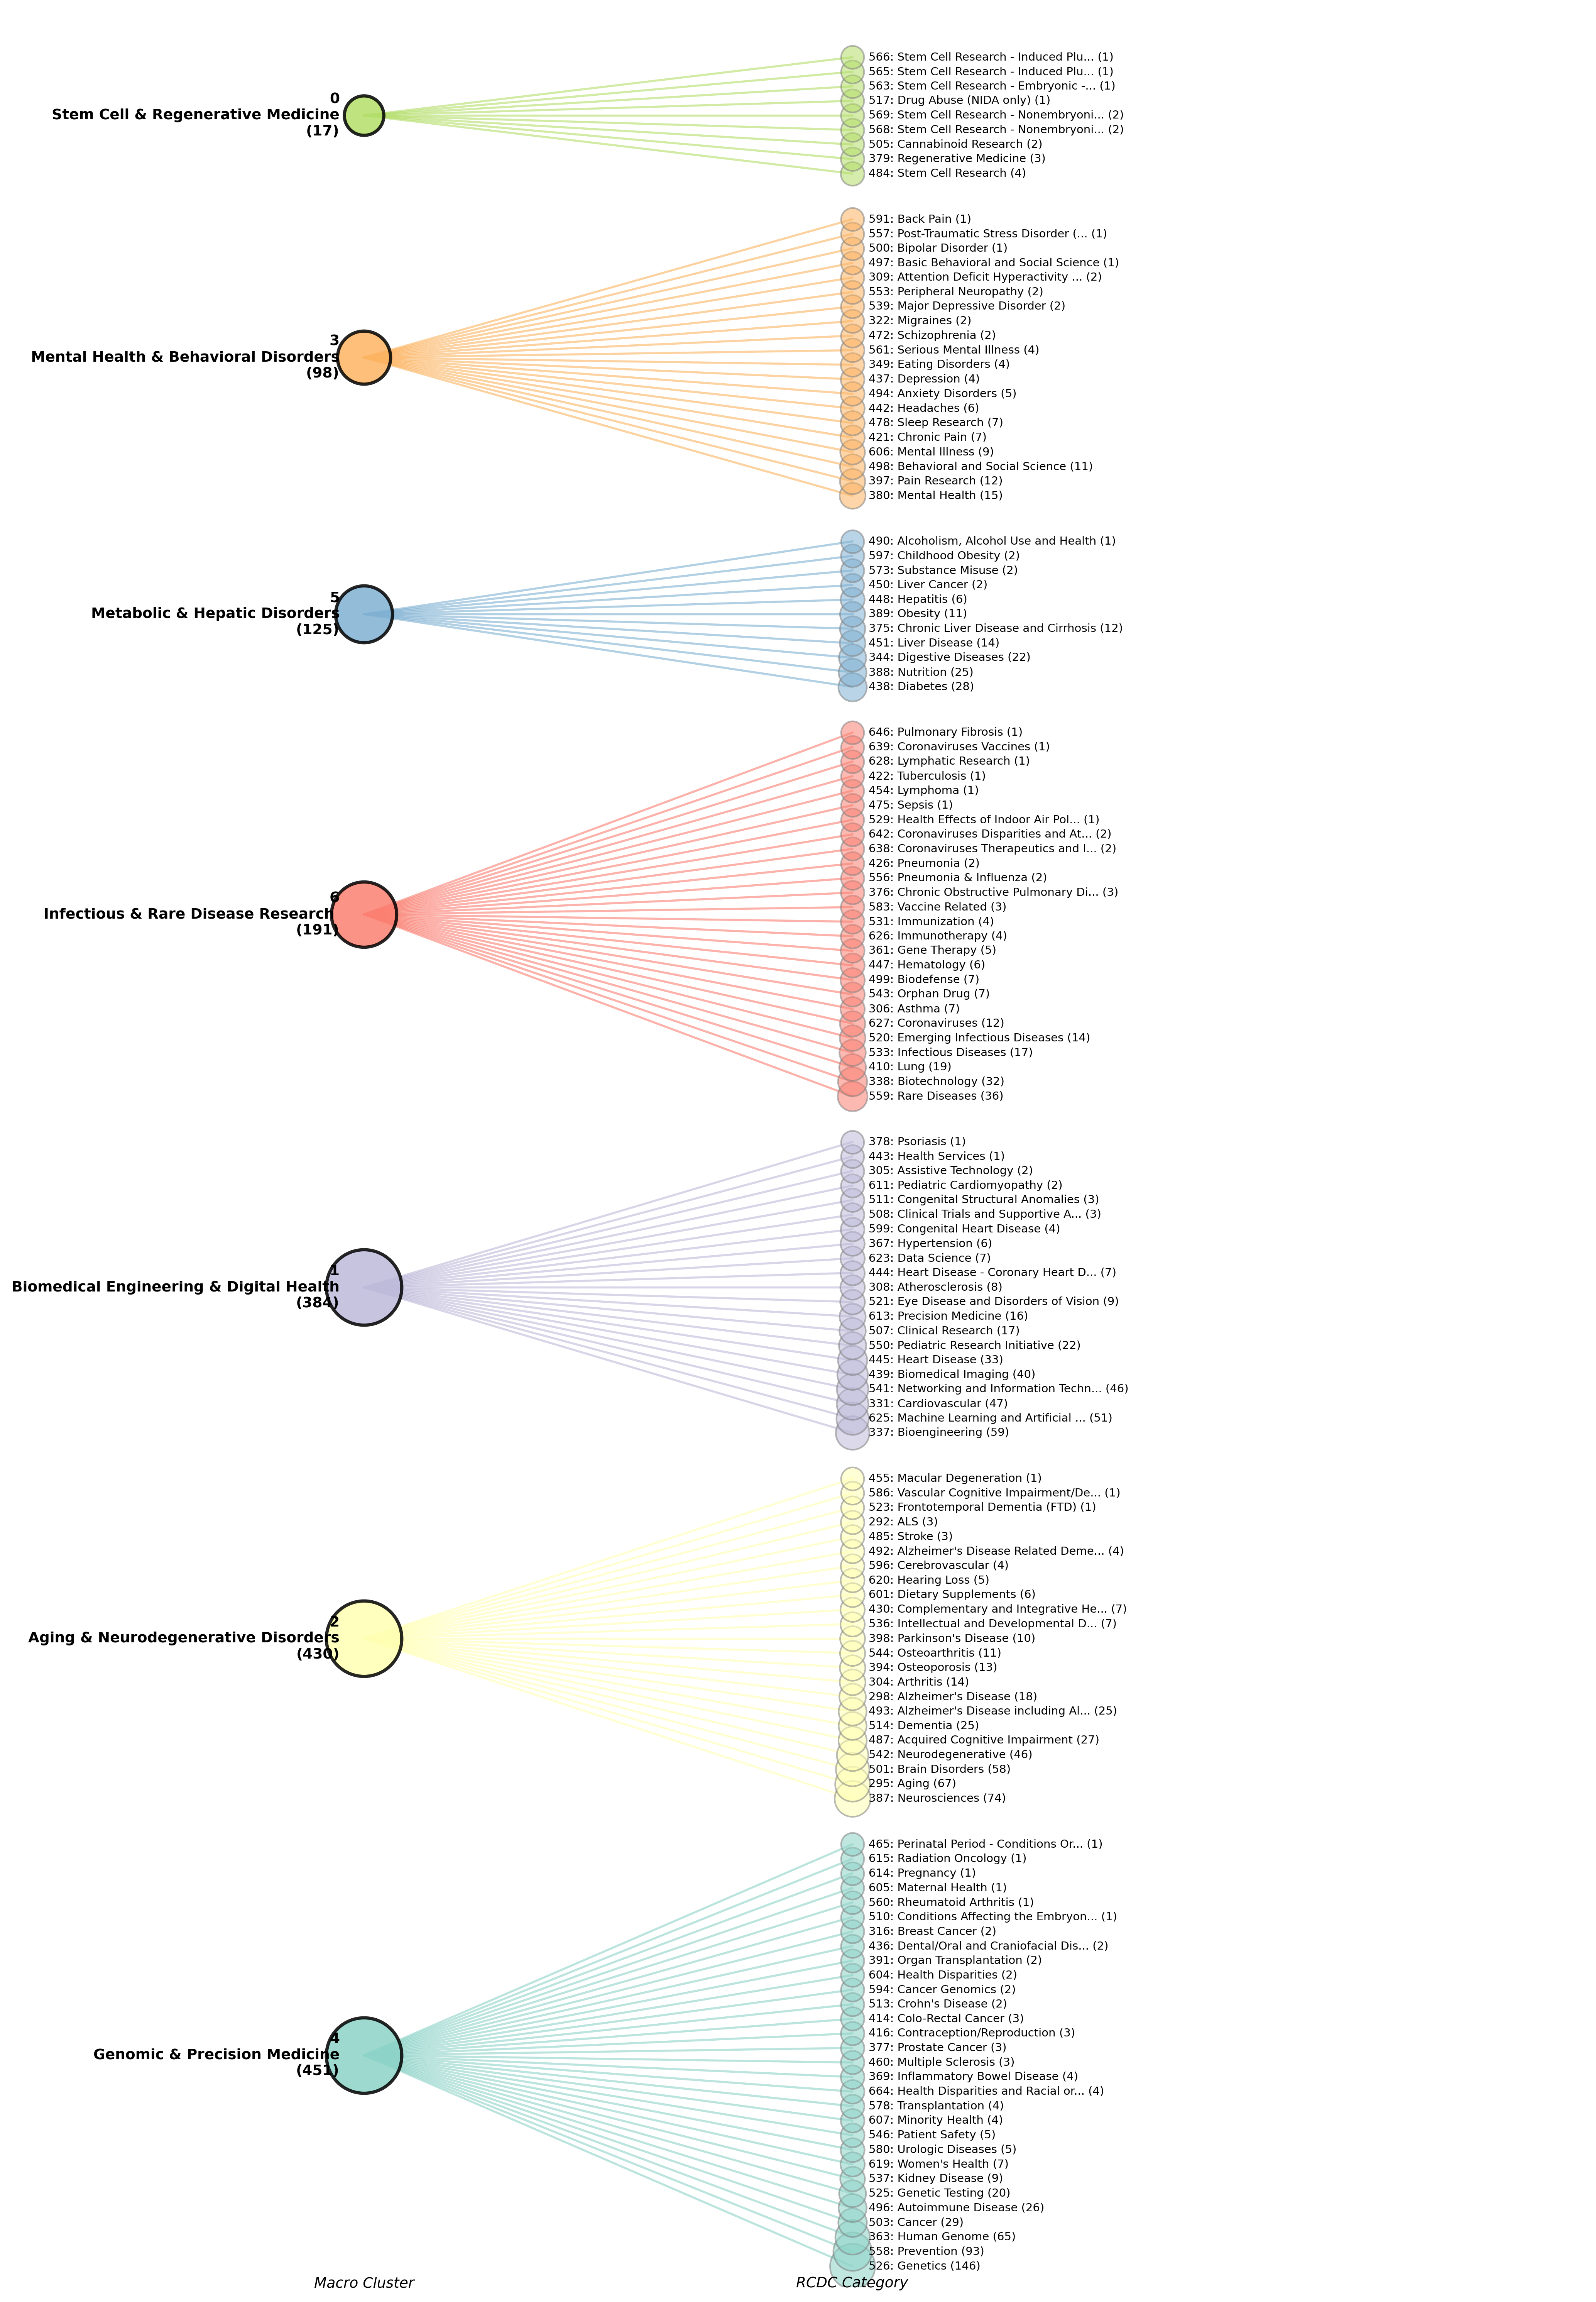

(<Figure size 4200x6000 with 1 Axes>, <Axes: >)

In [9]:
# RCDC tree-style hierarchy plot
patent.plot_rcdc_macro_hierarchy(
    df_with_iso,
    rcdc_context,
    category_col='category_rcdc',
    top_level_topics_col='top_level_topics',
    top_macro=8,
    figsize=(14, 20),
    savefile=None,
)

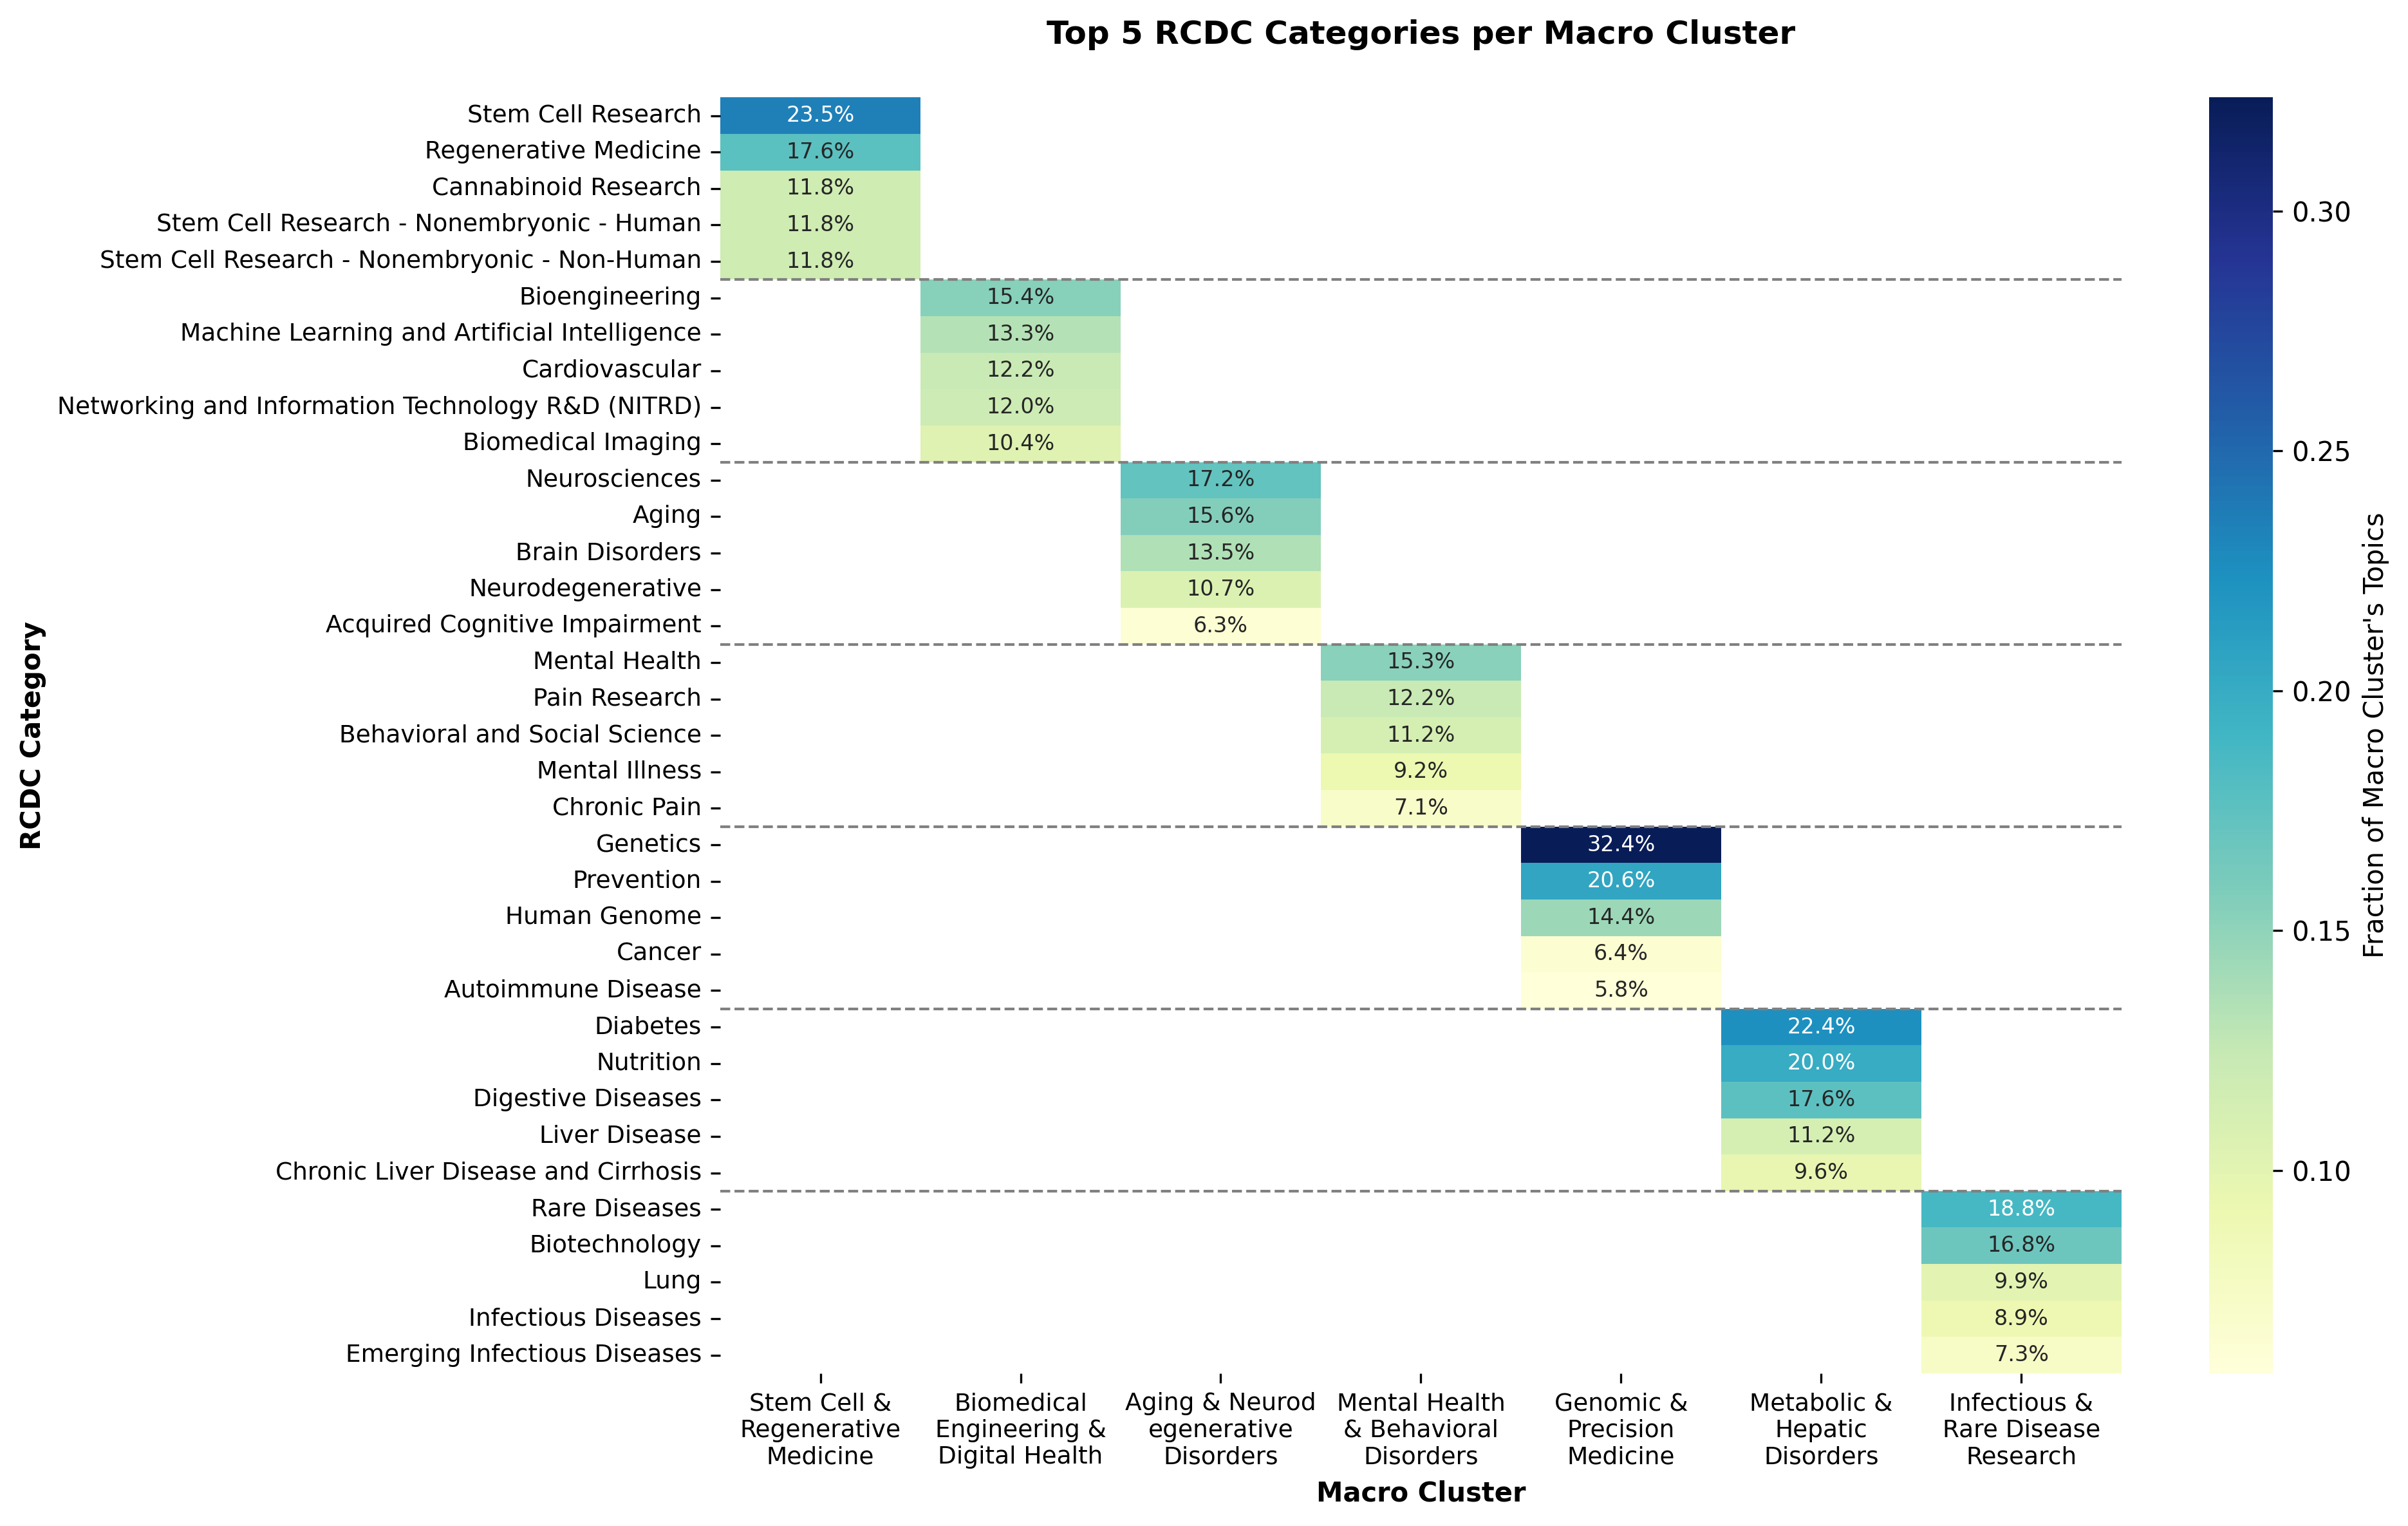

(<Figure size 3900x2400 with 2 Axes>,
 <Axes: title={'center': 'Top 5 RCDC Categories per Macro Cluster'}, xlabel='Macro Cluster', ylabel='RCDC Category'>,
                                                    Stem Cell & Regenerative Medicine  \
 Stem Cell Research                                                               4.0   
 Regenerative Medicine                                                            3.0   
 Cannabinoid Research                                                             2.0   
 Stem Cell Research - Nonembryonic - Human                                        2.0   
 Stem Cell Research - Nonembryonic - Non-Human                                    2.0   
 Bioengineering                                                                   NaN   
 Machine Learning and Artificial Intelligence                                     NaN   
 Cardiovascular                                                                   NaN   
 Networking and Information Technology R&D 

In [10]:
# RCDC categories per macro cluster heatmap
patent.plot_rcdc_macro_heatmap(
    df_with_iso,
    rcdc_context,
    category_col='category_rcdc',
    top_n_categories=5,
    normalize=True,
    figsize=(13, 8),
    savefile='fig/patent/rcdc_macro_heatmap.svg',
)

## 5. Geographic, Topic, and Network Analysis

Explore country patterns, topic hierarchies, co-occurrence structure, and topic diversity.

✓ Countries with patent counts: 24
✓ Total assignee-country occurrences: 604


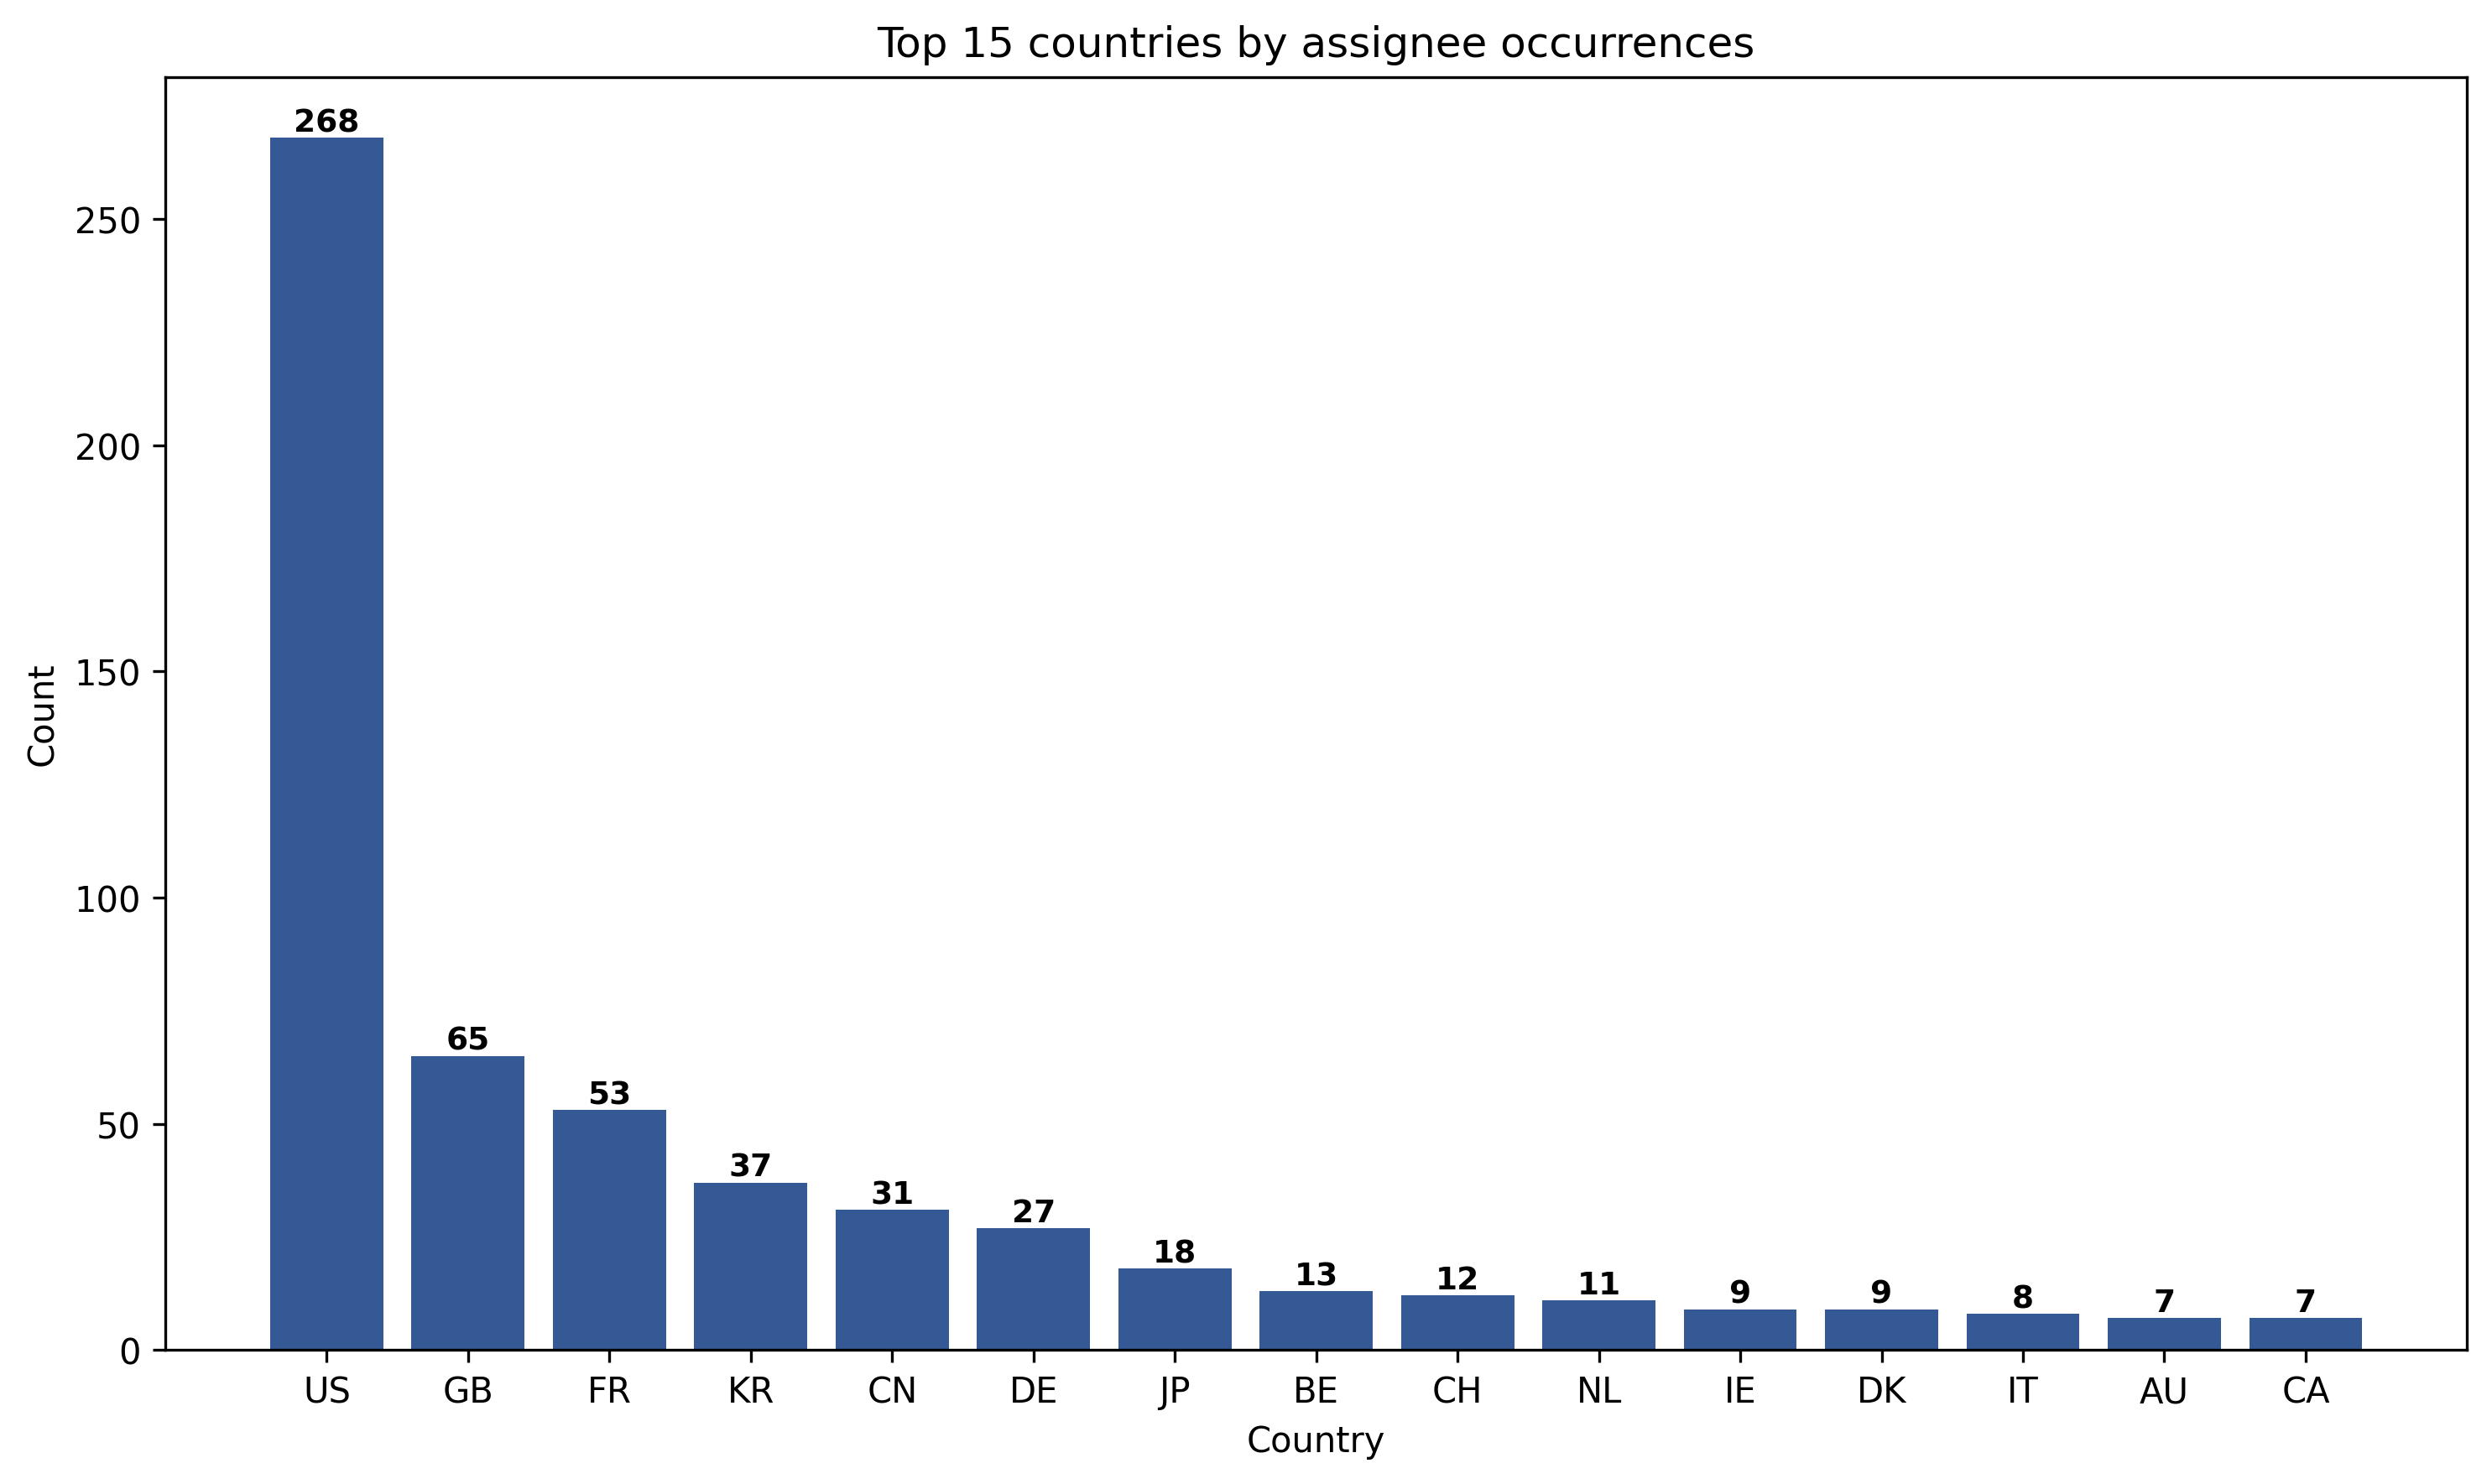

In [11]:
# Geographic analysis
country_df = patent.build_country_count(df_with_iso)
print(f"✓ Countries with patent counts: {len(country_df)}")
print(f"✓ Total assignee-country occurrences: {int(country_df['count'].sum())}")

patent.plot_bar_matplotlib(country_df, top_n=15, colors=colors_scheme[3], figsize=(10, 6), savefile=None)

✓ Patents with hierarchical topic data: 513
✓ Average topics per patent: 3.23
✓ Median topics per patent: 3


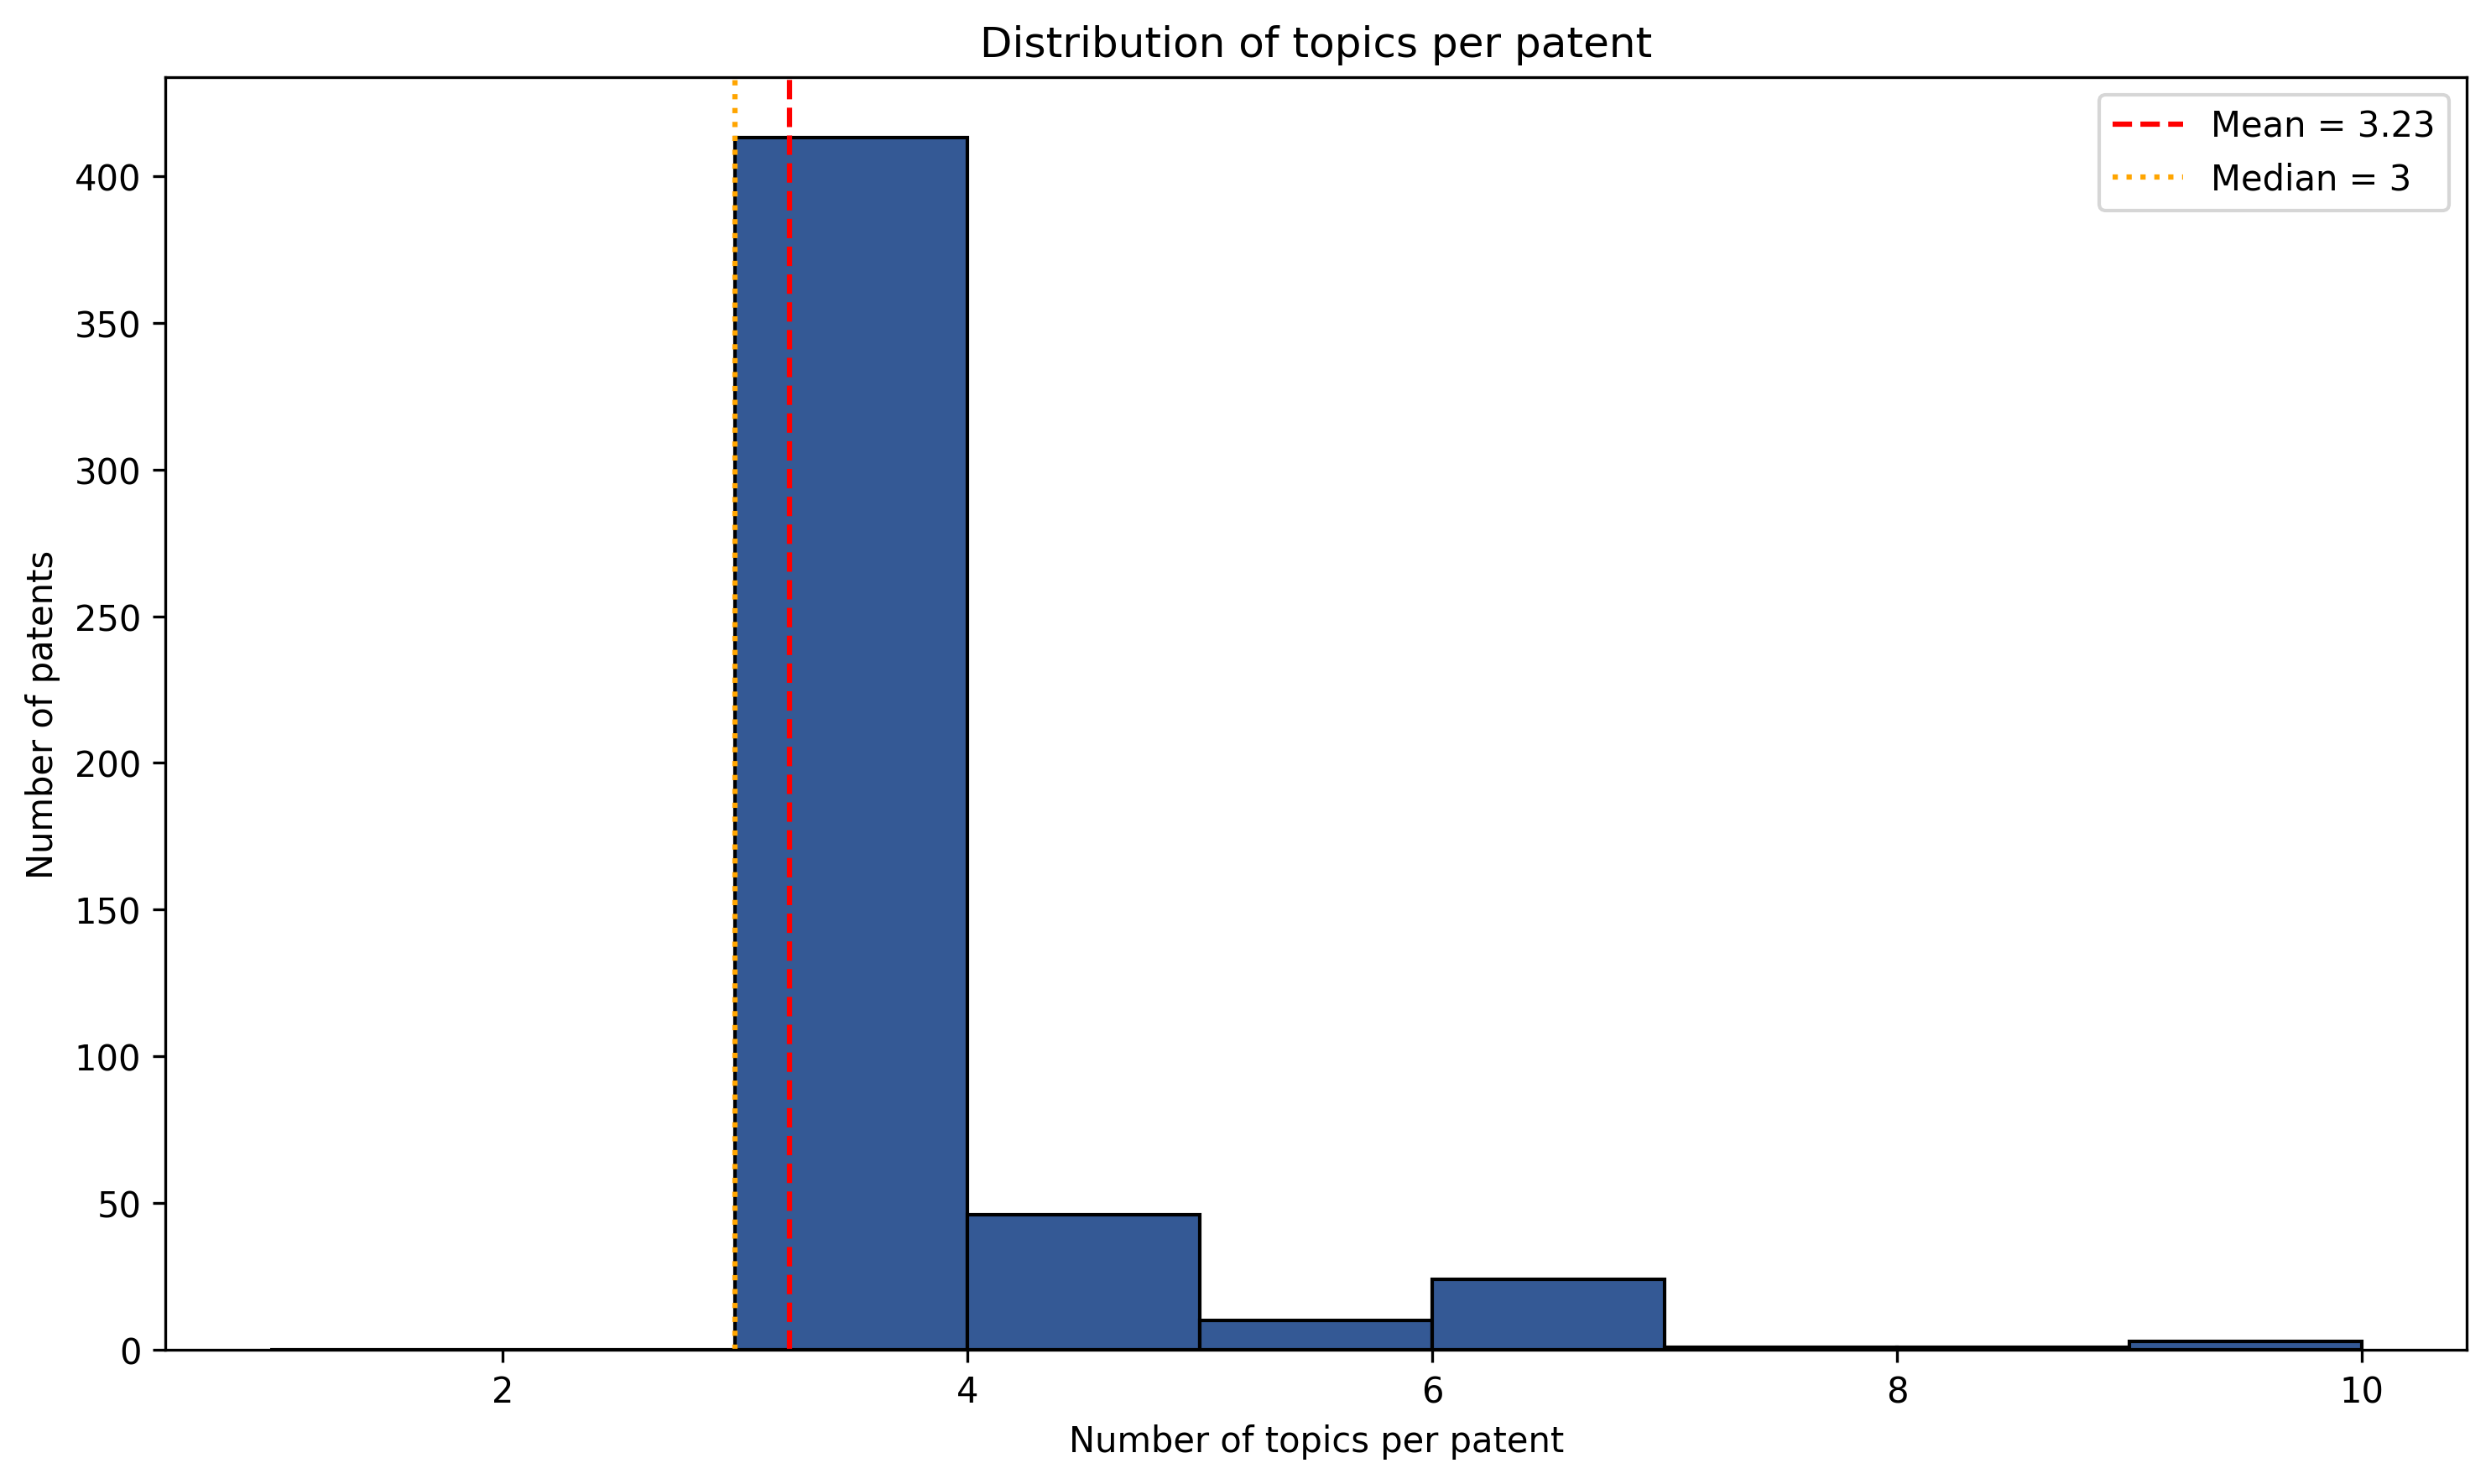

✓ Found 12 unique top-level topics


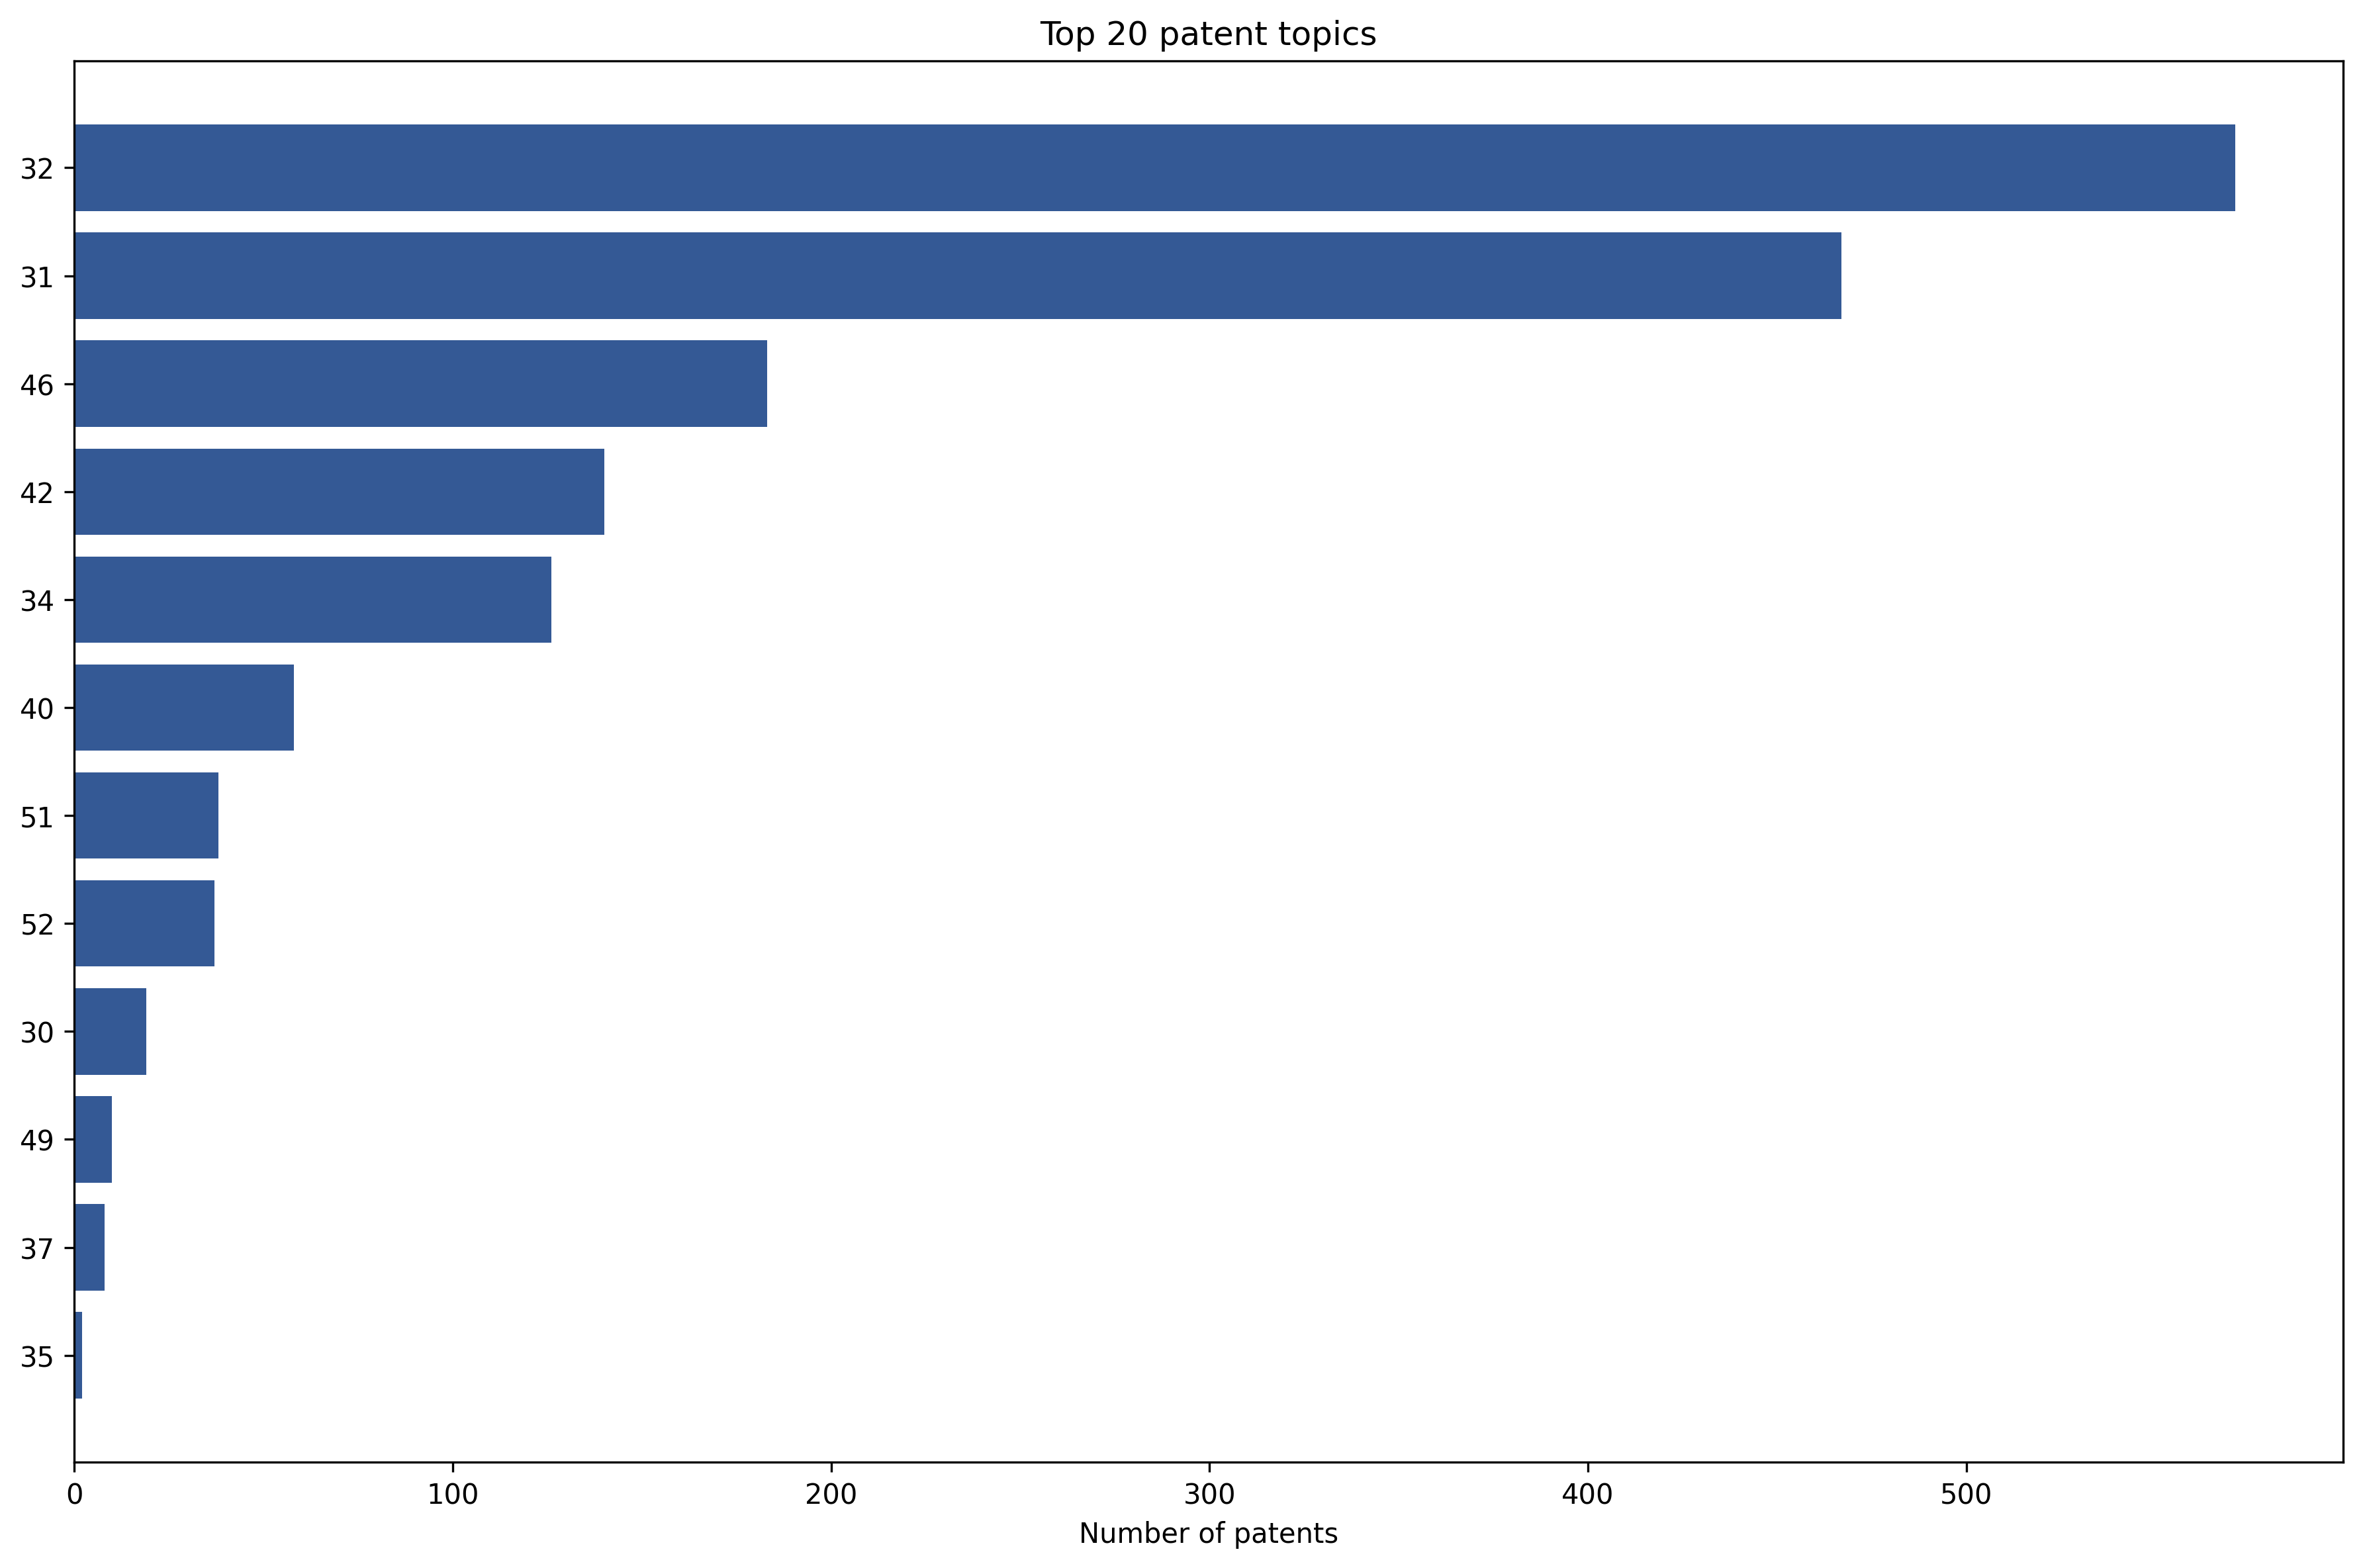

In [12]:
# Topic hierarchy and frequency analysis
df_with_iso['top_level_topics'] = df_with_iso['category_for'].apply(patent.safe_parse_category).apply(patent.collapse_to_top_level)
df_with_iso['topic_count'] = df_with_iso['top_level_topics'].apply(lambda topics: len(topics) if isinstance(topics, list) else 0)

topcode_to_label = {}
for topics in df_with_iso['top_level_topics']:
    if isinstance(topics, list):
        for code, label in topics:
            if code and label and code not in topcode_to_label:
                topcode_to_label[code] = label

print(f"✓ Patents with hierarchical topic data: {df_with_iso['top_level_topics'].notna().sum()}")
print(f"✓ Average topics per patent: {df_with_iso['topic_count'].mean():.2f}")
print(f"✓ Median topics per patent: {df_with_iso['topic_count'].median():.0f}")

patent.plot_topics_histogram(
    df_with_iso,
    n_topics_col='topic_count',
    colors=colors_scheme[3],
    figsize=(10, 6),
    savefile=None,
)

topic_counter = Counter()
for topics in df_with_iso['top_level_topics']:
    if isinstance(topics, list):
        for code, _ in topics:
            if code:
                topic_counter[code] += 1

topic_df = (
    pd.DataFrame(topic_counter.items(), columns=['topic', 'count'])
    .sort_values('count', ascending=False)
    .reset_index(drop=True)
)
print(f"✓ Found {len(topic_df)} unique top-level topics")

patent.plot_top_topics_horizontal(
    topic_df,
    topic_col='topic',
    count_col='count',
    top_n=20,
    colors=[colors_scheme[3]],
    figsize=(12, 8),
    savefile=None,
)

Single-topic patents: 0 (0.0%)
Multi-topic patents: 498 (97.1%)

Top self-sustaining topics:



Co-occurrence graph nodes: 9
Co-occurrence graph edges: 12


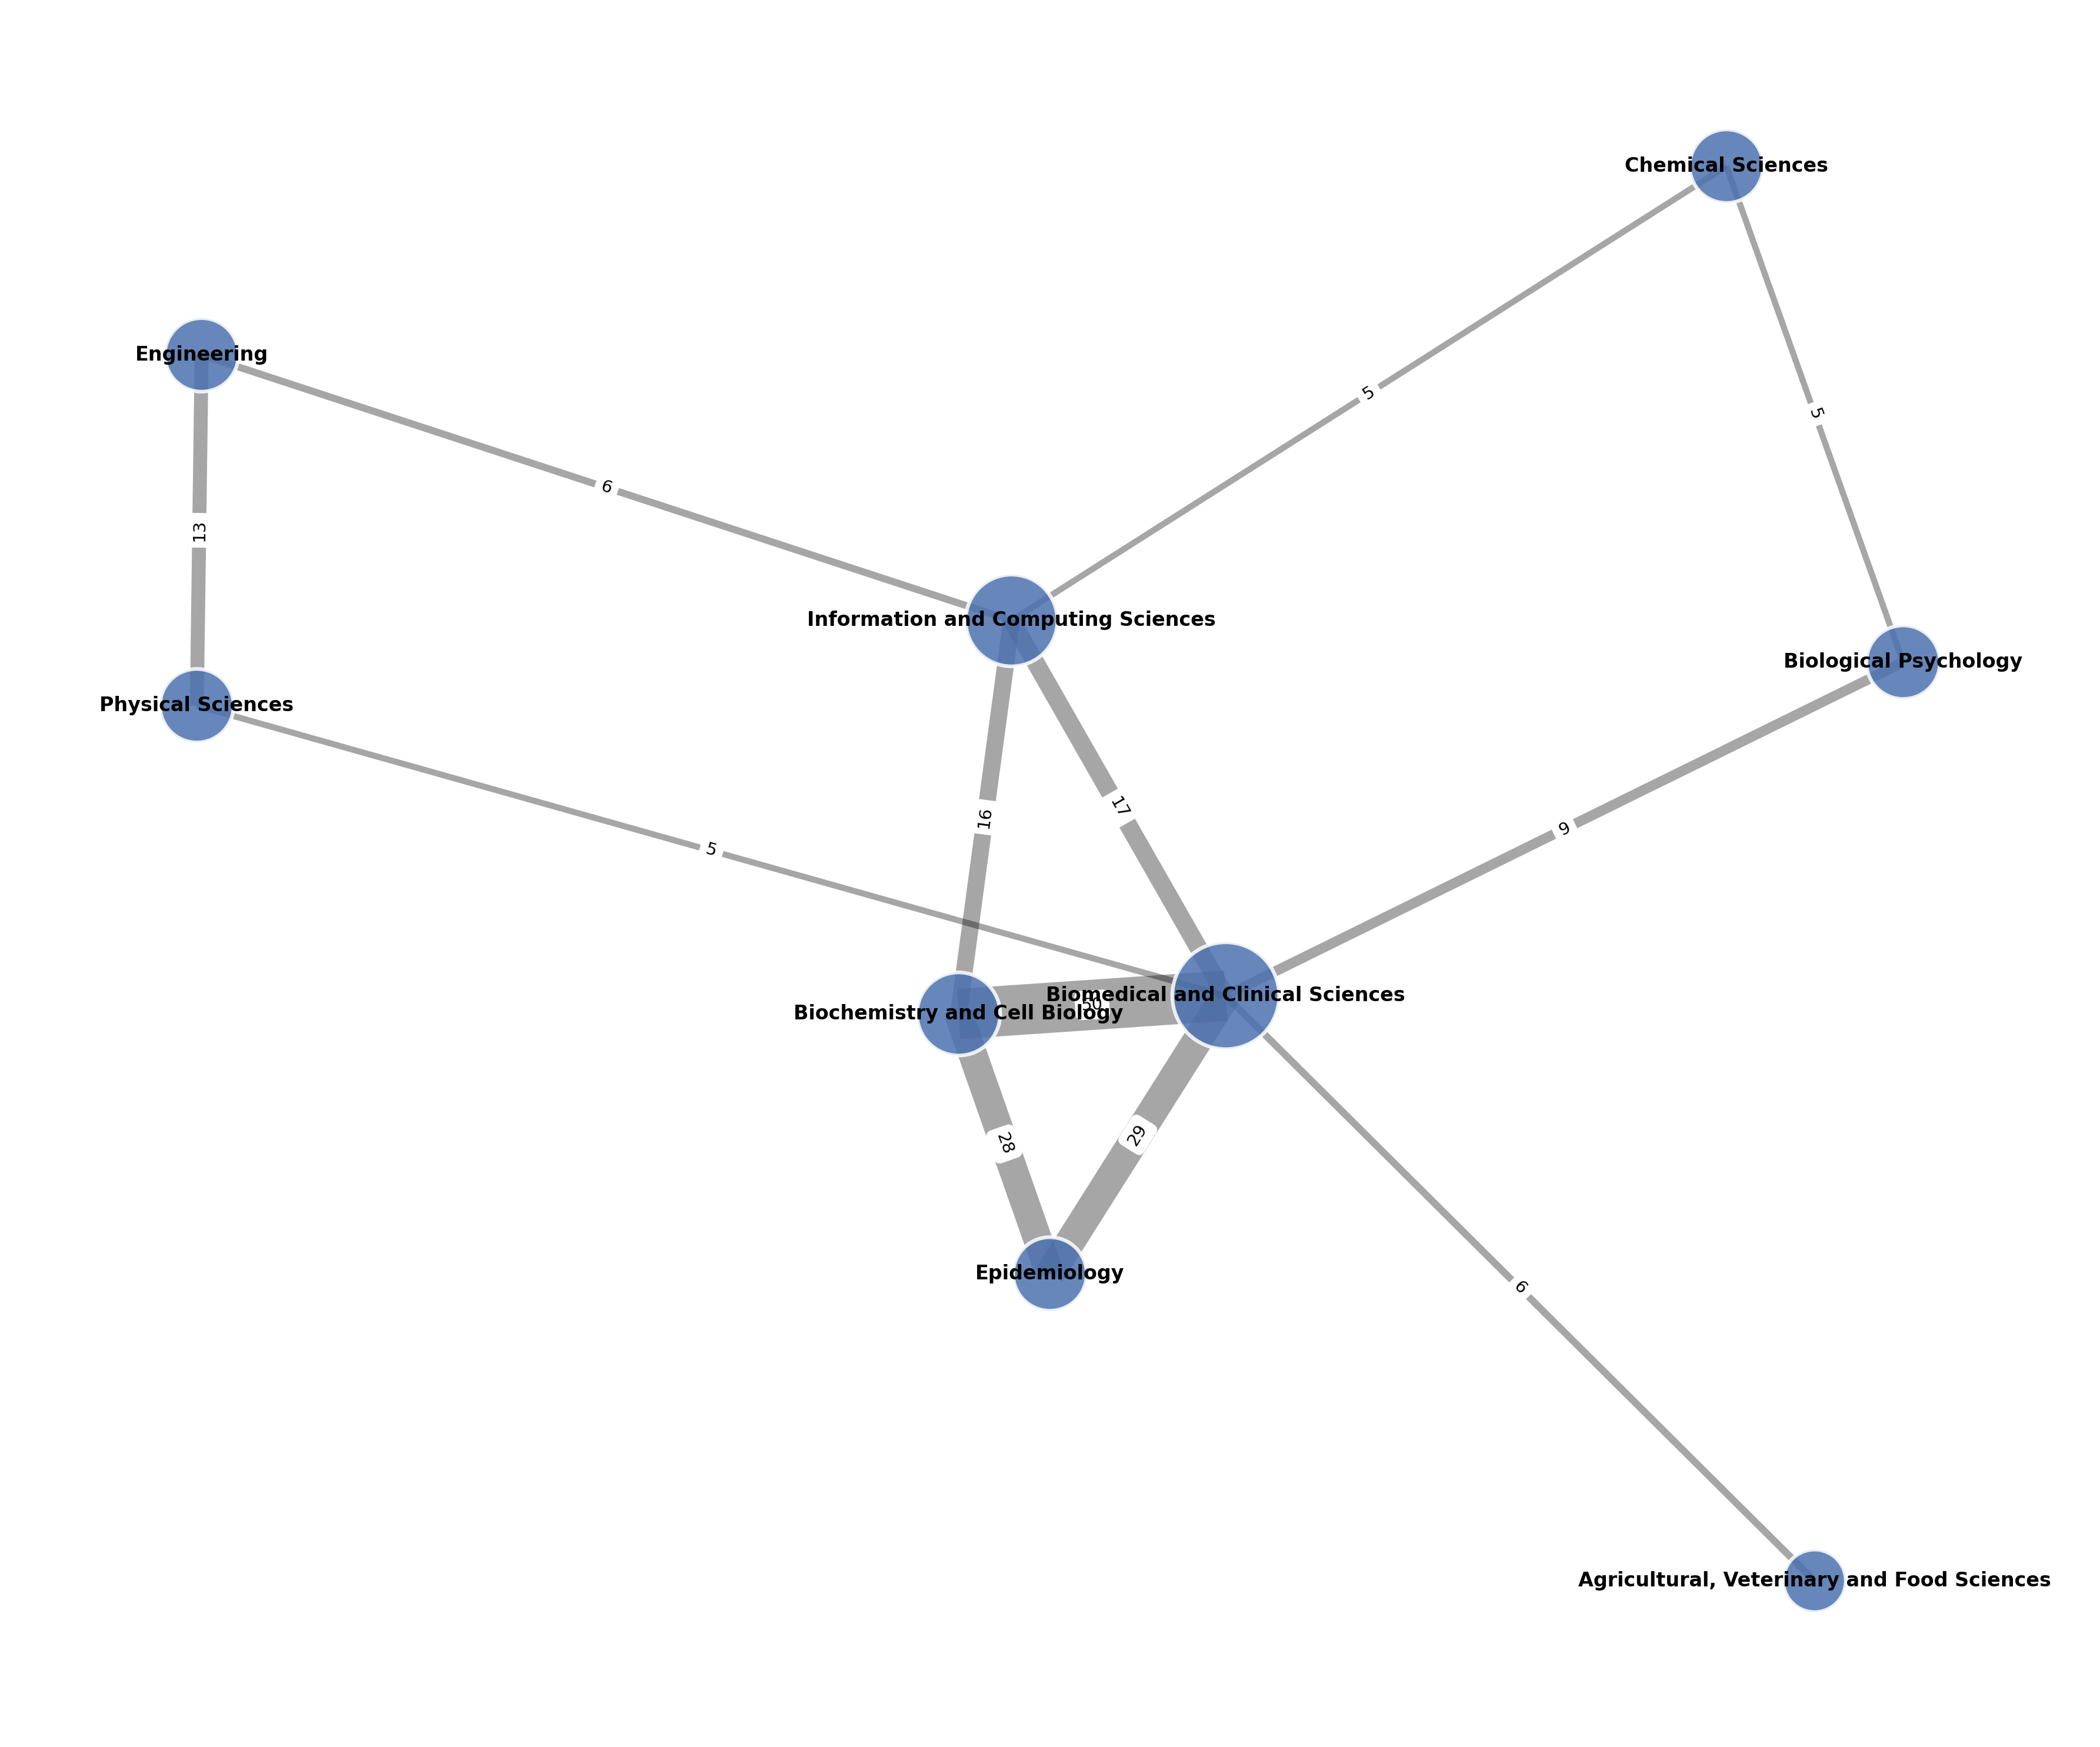

(<Figure size 3600x3000 with 1 Axes>, <Axes: >)

In [13]:
# Topic co-occurrence and sustainability analysis
single_topic_patents = df_with_iso[df_with_iso['topic_count'] == 1]
multi_topic_patents = df_with_iso[df_with_iso['topic_count'] >= 2]

print(f"Single-topic patents: {len(single_topic_patents)} ({len(single_topic_patents) / len(df_with_iso) * 100:.1f}%)")
print(f"Multi-topic patents: {len(multi_topic_patents)} ({len(multi_topic_patents) / len(df_with_iso) * 100:.1f}%)")

single_topic_counter = Counter()
for topics in single_topic_patents['top_level_topics']:
    if isinstance(topics, list):
        for code, _ in topics:
            if code:
                single_topic_counter[code] += 1

print("\nTop self-sustaining topics:")
for code, count in single_topic_counter.most_common(10):
    print(f"  {code}: {count}")

co_graph, pair_counter = patent.build_topic_cooccurrence_network(
    df_with_iso,
    topics_col='top_level_topics',
    min_weight=5,
)
print(f"\nCo-occurrence graph nodes: {co_graph.number_of_nodes()}")
print(f"Co-occurrence graph edges: {co_graph.number_of_edges()}")

patent.plot_topic_cooccurrence_network(
    co_graph,
    code_to_label=topcode_to_label,
    figsize=(12, 10),
    savefile=None,
)

✓ Countries with topic data: 24
✓ Topics in country matrix: 12


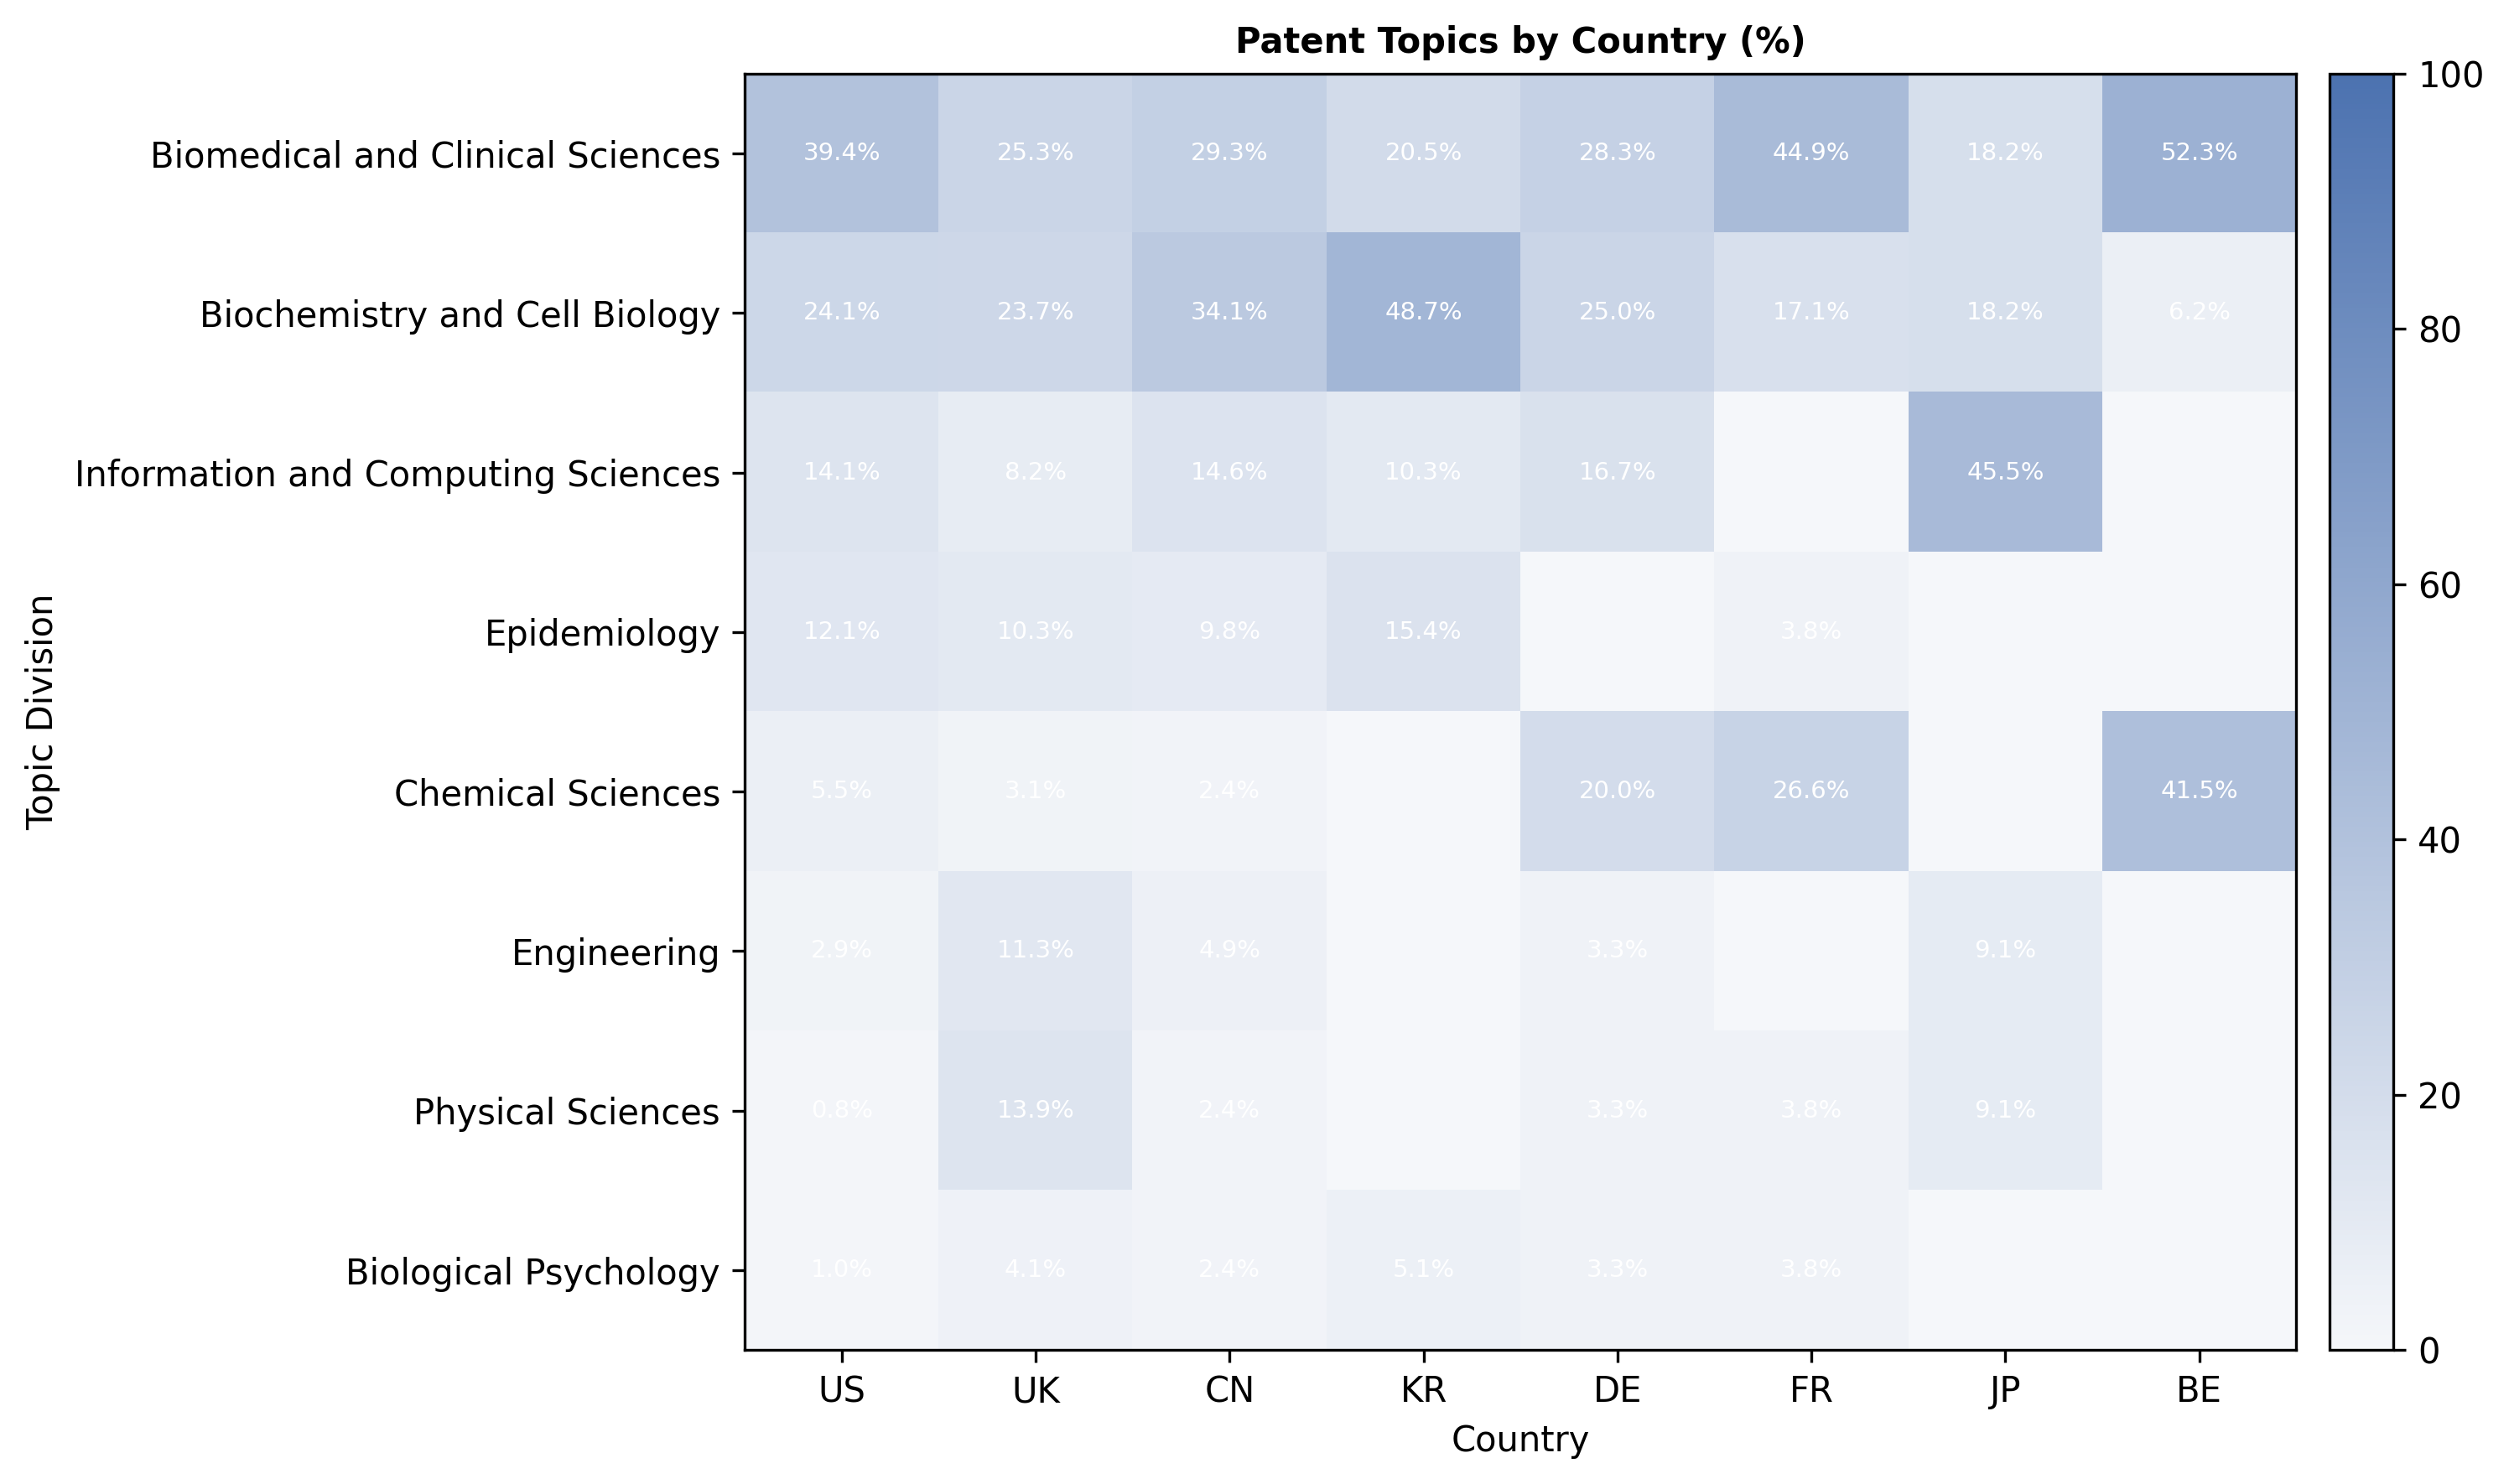

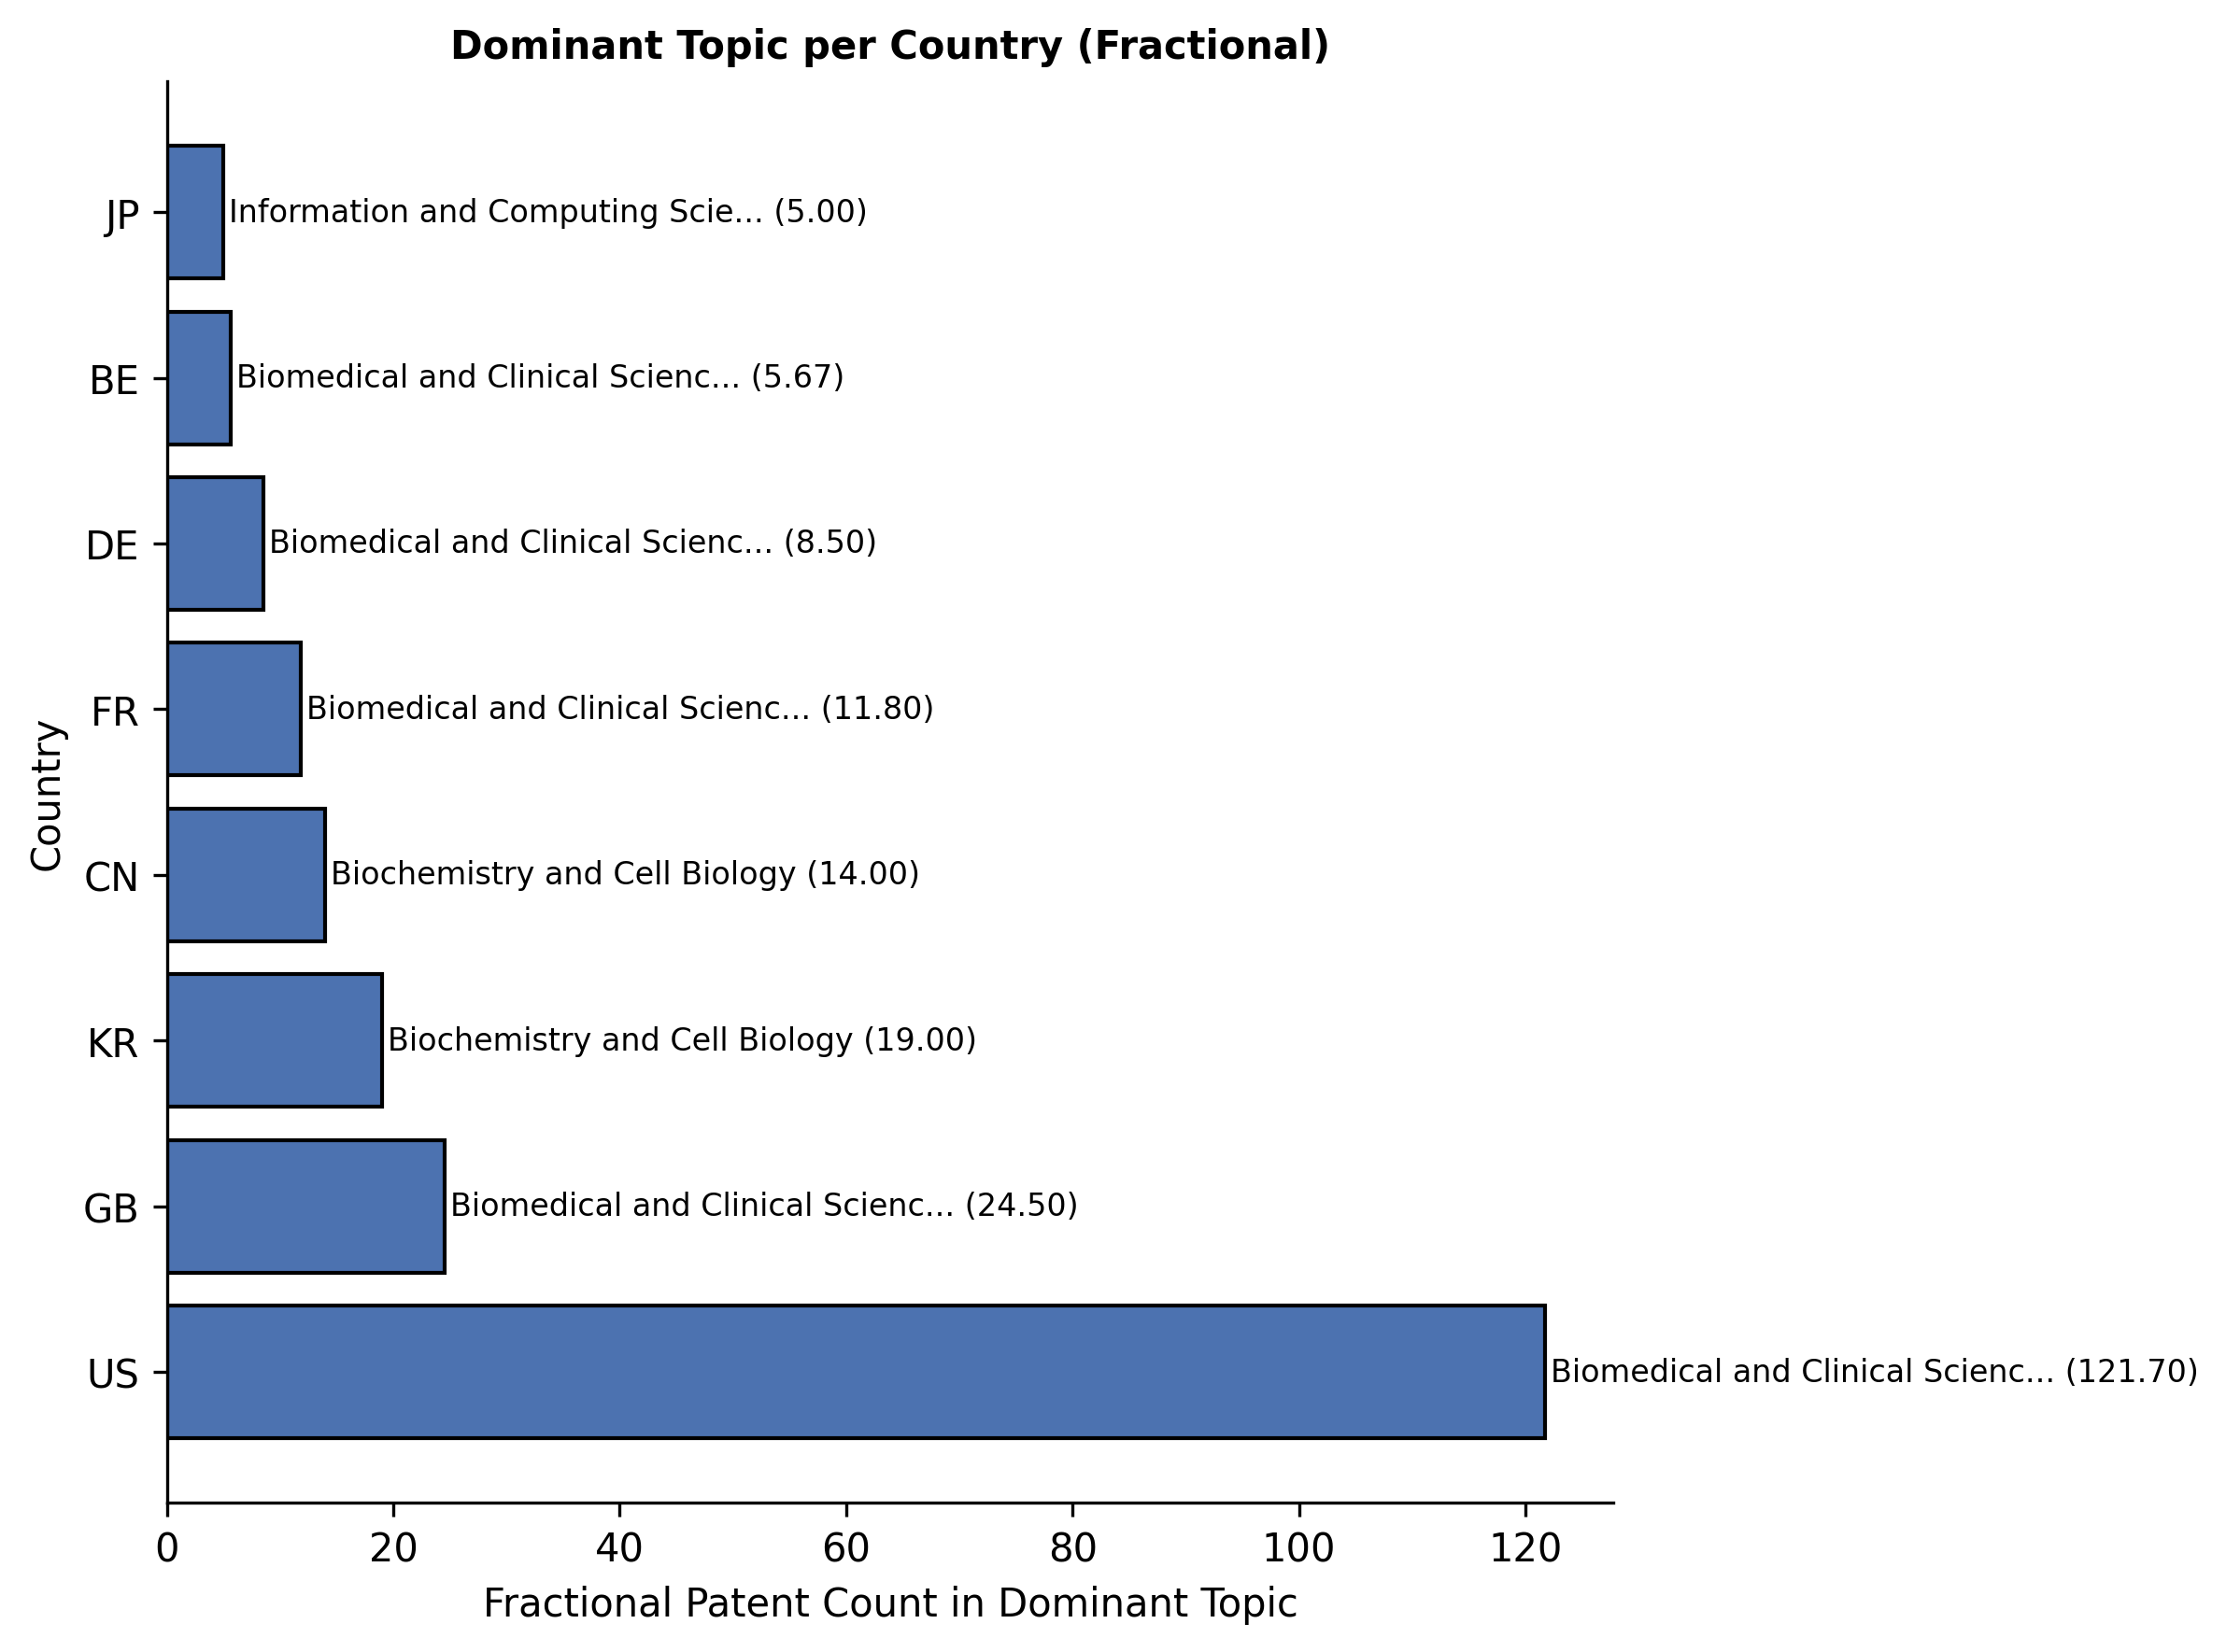

In [ ]:
# Patent topics by country
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(
    'custom_cmap',
    [colors_scheme[3], colors_scheme[0]]
)

country_topic_rows, pivot_country_topic, top_countries, top_topic_codes, country_counter, topic_counter_frac = patent.analyze_country_topics(
    df_with_iso,
    topics_col='top_level_topics',
    country_col='assignee_countries',
    code_to_label=topcode_to_label,
    top_countries=8,
    top_topics=8,
)

if not country_topic_rows.empty:
    topic_by_country = (
        country_topic_rows.groupby(['country', 'topic_code', 'topic_label'])['weight']
        .sum()
        .reset_index(name='count')
    )
    print(f"✓ Countries with topic data: {topic_by_country['country'].nunique()}")
    print(f"✓ Topics in country matrix: {topic_by_country['topic_code'].nunique()}")

    patent.plot_country_topic_heatmap(
        pivot_country_topic,
        code_to_label=topcode_to_label,
        figsize=(10, 6),
        savefile=None,
        cmap=cmap
    )

    patent.plot_country_dominant_topics(
        topic_by_country,
        top_countries=top_countries,
        code_to_label=topcode_to_label,
        figsize=(8, 6),
        savefile=None,
    )
else:
    print('No country-topic data available for visualization.')

(<Figure size 3000x1800 with 1 Axes>,
 <Axes: title={'center': 'Patent Counts by Filing Status and Publication Year'}, xlabel='Publication Year', ylabel='Number of Patents'>)

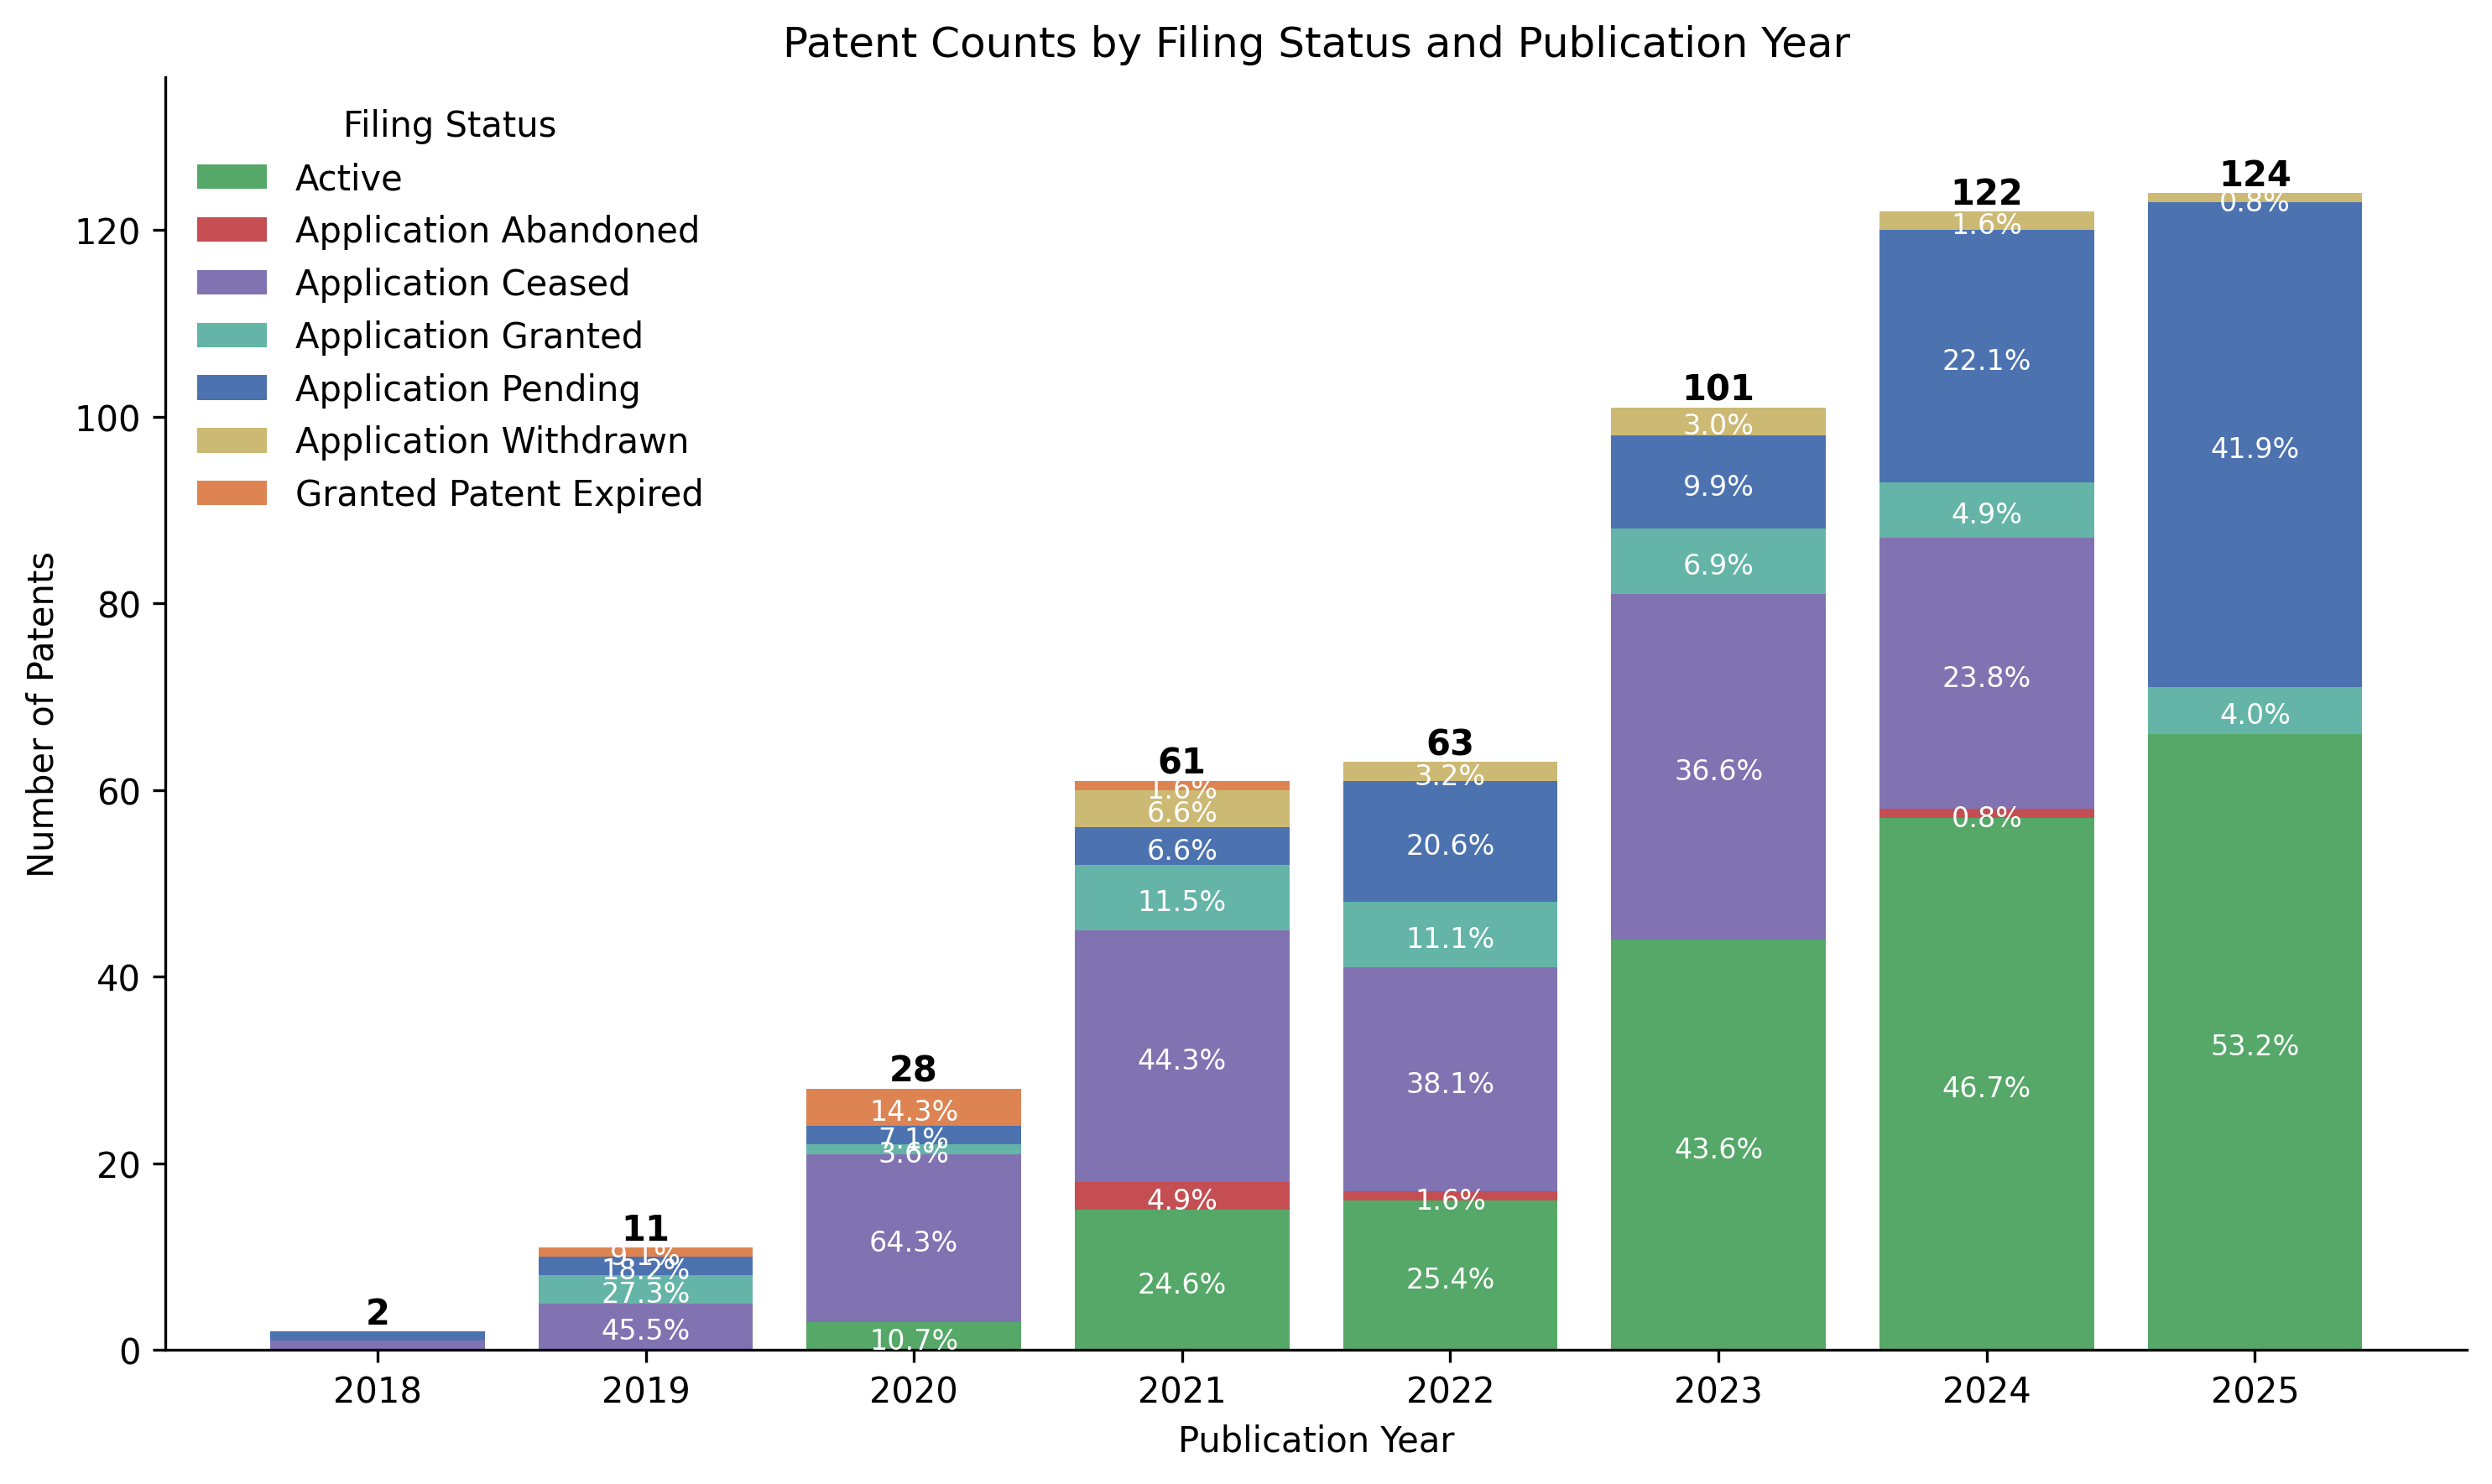

In [15]:
# Filing status over time (source-faithful to original notebook)
col = 'legal_status_replaced'
patent.plot_filing_status_over_time(df_with_iso, col, figsize=(10, 6), savefigure=False)

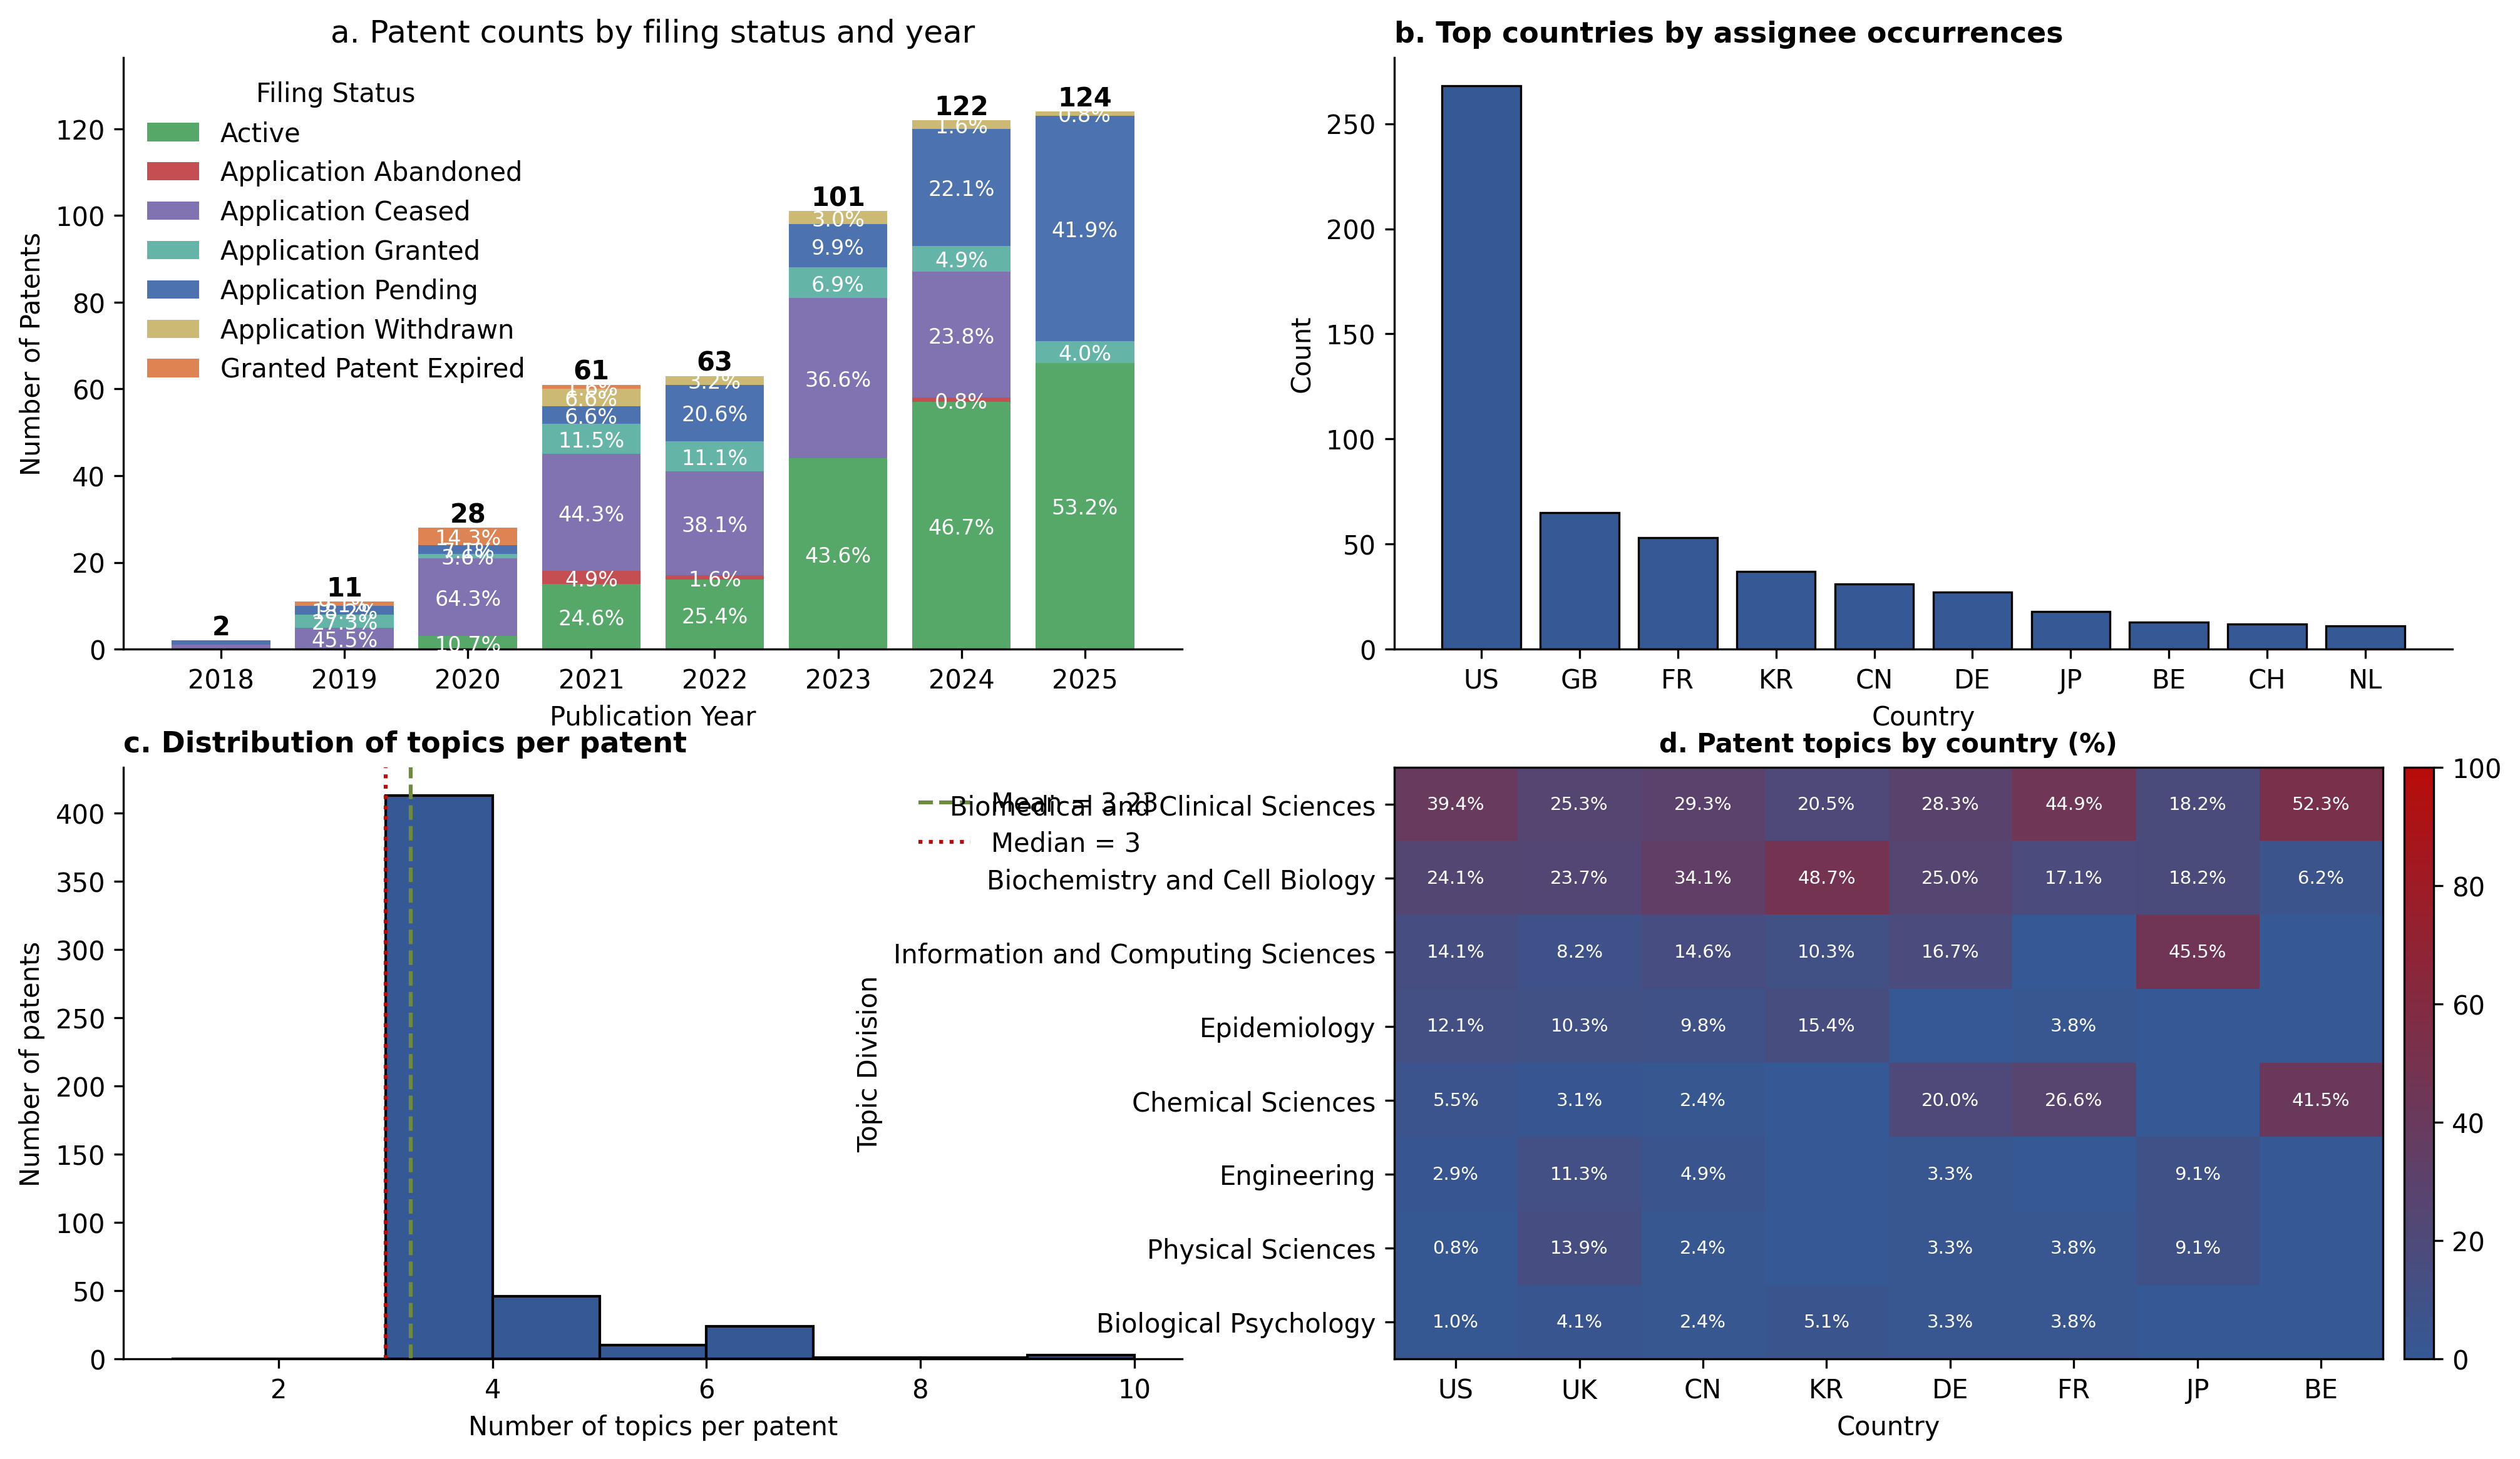

<Figure size 1920x1440 with 0 Axes>

In [16]:
# Assembled summary visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# a. Filing status over time
col = 'legal_status_replaced'
patent.plot_filing_status_over_time(df_with_iso, col, figsize=(10, 6), savefigure=False, ax=axes[0, 0], title='a. Patent counts by filing status and year')

# b. Top countries by assignee occurrences
top_country_counts = country_df.sort_values('count', ascending=False).head(10)
axes[0, 1].bar(top_country_counts['iso2'], top_country_counts['count'], color=colors_scheme[3], edgecolor='black', linewidth=0.8)
axes[0, 1].set_title('b. Top countries by assignee occurrences', fontsize=11, fontweight='bold', loc='left')
axes[0, 1].set_xlabel('Country')
axes[0, 1].set_ylabel('Count')
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)

# c. Distribution of topics per patent
axes[1, 0].hist(df_with_iso['topic_count'], bins=range(1, int(df_with_iso['topic_count'].max()) + 2), edgecolor='black', color=colors_scheme[3])
axes[1, 0].axvline(df_with_iso['topic_count'].mean(), linestyle='--', color=colors_scheme[2], label=f"Mean = {df_with_iso['topic_count'].mean():.2f}")
axes[1, 0].axvline(df_with_iso['topic_count'].median(), linestyle=':', color=colors_scheme[0], label=f"Median = {df_with_iso['topic_count'].median():.0f}")
axes[1, 0].legend(frameon=False)
axes[1, 0].set_title('c. Distribution of topics per patent', fontsize=11, fontweight='bold', loc='left')
axes[1, 0].set_xlabel('Number of topics per patent')
axes[1, 0].set_ylabel('Number of patents')
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)

# d. Patent topics by country (%)
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(
    'custom_cmap',
    [colors_scheme[3], colors_scheme[0]]
)
patent.plot_country_topic_heatmap(
    pivot_country_topic,
    code_to_label=topcode_to_label,
    figsize=(10, 6),
    savefile=None,
    ax=axes[1, 1],
    cmap=cmap,
    title='d. Patent topics by country (%)',
)

plt.tight_layout()
plt.show()

Saved showcase subset with 512 patents to /Users/valler/Python/RA/20_years_of_ukb/data/analysis/non_academic/patent/df_patent_showcase.csv


Found 372 UKBB papers cited by patents
Total citation events: 785


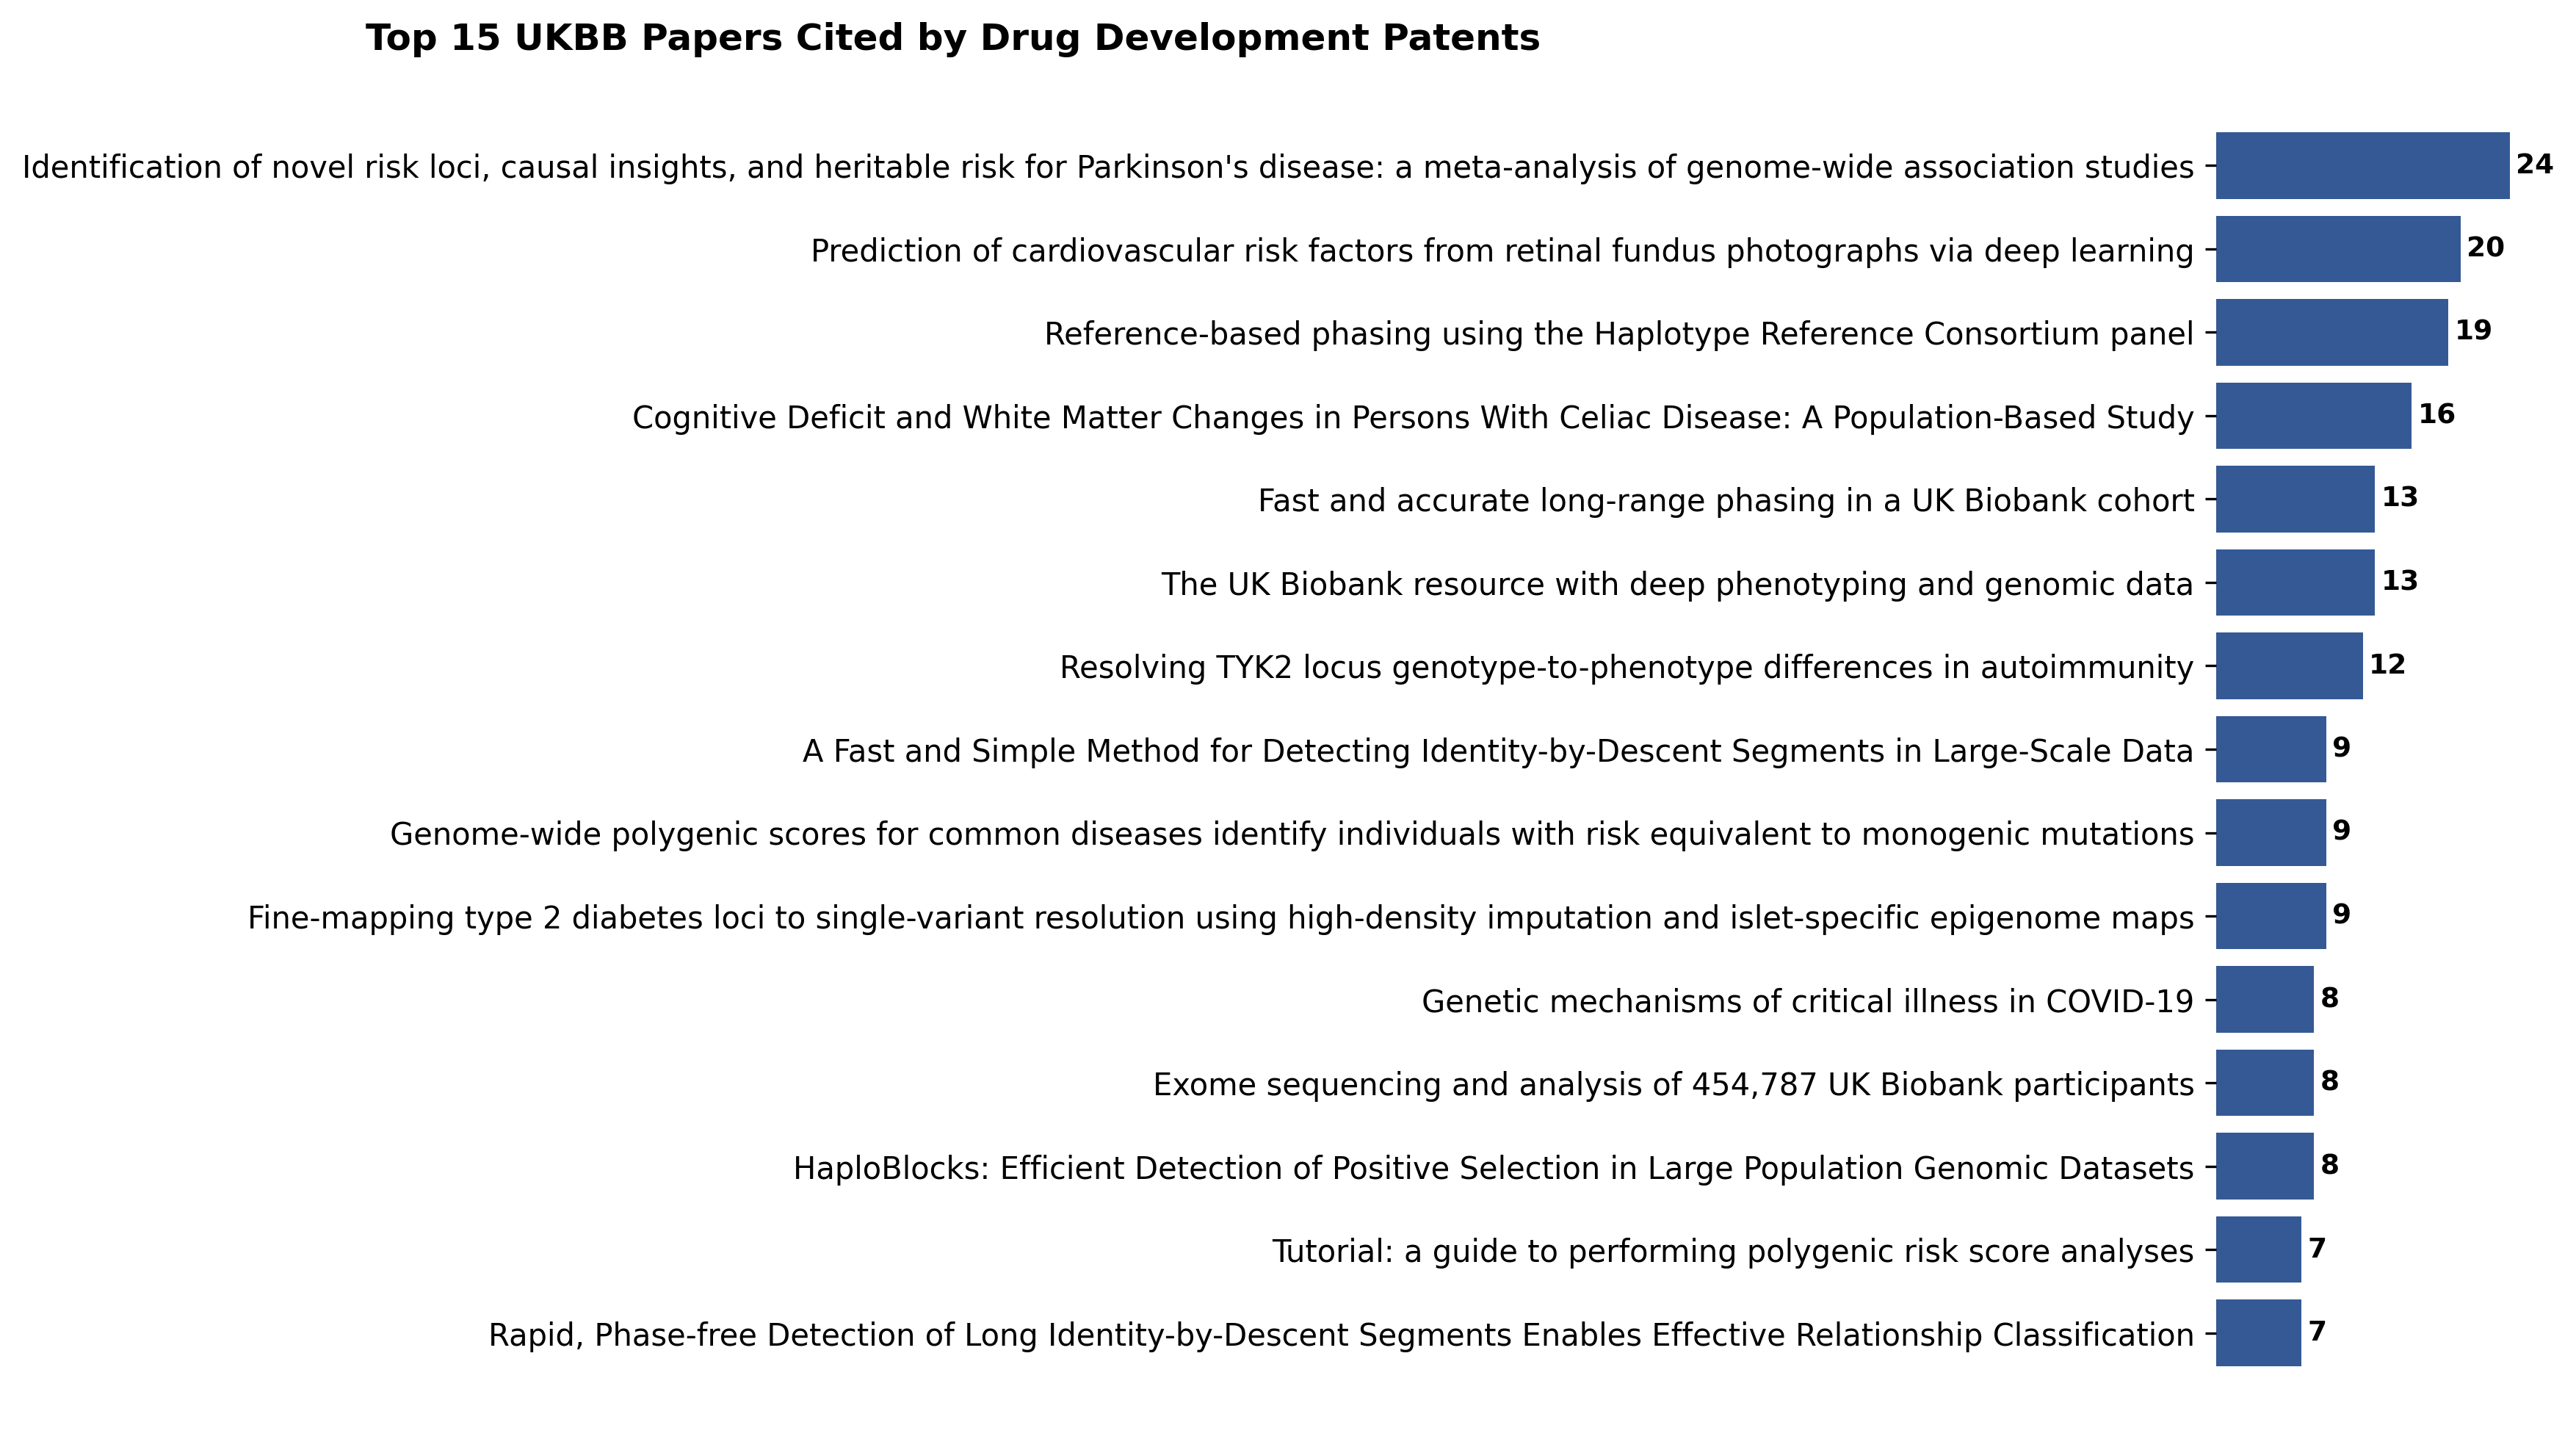

Saved modularized analysis dataset to /Users/valler/Python/RA/20_years_of_ukb/data/analysis/non_academic/patent/patents_modularized_export.csv


In [17]:
# Export showcase data and UKBB citation analysis
showcase_cols = [
    col for col in [
        'id', 'title', 'abstract_clean', 'publication_date', 'publication_year',
        'assignee_country_primary', 'assignee_countries', 'filing_status',
        'category_for', 'topic_count'
    ]
    if col in df_with_iso.columns
]

df_patent_showcase = df_with_iso.copy()
if 'filing_status' in df_patent_showcase.columns:
    filing_status_values = set(df_patent_showcase['filing_status'].dropna().astype(str))
    preferred_statuses = [status for status in ['Application', 'Grant'] if status in filing_status_values]
    if preferred_statuses:
        df_patent_showcase = df_patent_showcase[df_patent_showcase['filing_status'].isin(preferred_statuses)].copy()

if df_patent_showcase.empty:
    df_patent_showcase = df_with_iso.copy()

df_patent_showcase = df_patent_showcase[showcase_cols].drop_duplicates(subset=['id']).copy()
P.PATENT.mkdir(parents=True, exist_ok=True)
showcase_path = P.PATENT / 'df_patent_showcase.csv'
df_patent_showcase.to_csv(showcase_path, index=False)
print(f"Saved showcase subset with {len(df_patent_showcase)} patents to {showcase_path}")

if 'publication_ids' in df_with_iso.columns:
    df_with_iso['in_ukbb'] = df_with_iso['publication_ids'].apply(
        lambda x: patent.find_ukbb_papers(x, df_all_ukbb['id'].tolist())
    )

    paper_counter = Counter()
    for papers in df_with_iso['in_ukbb']:
        for paper_id in papers:
            paper_counter[paper_id] += 1

    df_ukbb_cited_papers = (
        pd.DataFrame(paper_counter.items(), columns=['id', 'count'])
        .sort_values('count', ascending=False)
        .reset_index(drop=True)
    )

    if not df_ukbb_cited_papers.empty:
        if 'id' in df_all_ukbb.columns:
            df_ukbb_cited_papers = df_ukbb_cited_papers.merge(df_all_ukbb, on='id', how='left')

        print(f"Found {len(df_ukbb_cited_papers)} UKBB papers cited by patents")
        print(f"Total citation events: {int(df_ukbb_cited_papers['count'].sum())}")

        patent.plot_top_cited_papers(
            df_ukbb_cited_papers,
            title_col='title',
            count_col='count',
            top_n=15,
            colors=[colors_scheme[3]],
            figsize=(14, 8),
            savefile=None,
        )
    else:
        print('No UKBB papers were cited by the current patent set.')
else:
    print('publication_ids column is missing; skipping UKBB citation analysis.')

output_path = P.PATENT / 'patents_modularized_export.csv'
df_with_iso.to_csv(output_path, index=False)
print(f"Saved modularized analysis dataset to {output_path}")